# Trabajo Práctico — Predicción de Precios de Propiedades
## Ejercicio 1: Análisis Exploratorio de Datos (EDA)

---

**Dataset:** `casas_dev.csv`  
**Objetivo:** Explorar la naturaleza del dataset, identificar problemas de calidad de datos y comprender las relaciones entre variables antes de construir un modelo de predicción.

In [239]:
# Imports y setup

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# --- Estilo global ---
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

PALETTE_MERCADO = {'Buenos Aires': '#2196F3', 'Nueva York': '#FF5722'}
PALETTE_TIPO    = {'casa': '#4CAF50', 'depto': '#9C27B0', 'ph': '#FF9800'}
SEED = 42

print('Librerías cargadas correctamente.')

sys.path.append("../src")

Librerías cargadas correctamente.


In [241]:
# Loading Dataset and reading sample

df = pd.read_csv("../data/raw/casas_dev.csv")

print(f'Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Columnas: {list(df.columns)}')

Dimensiones: 1,600 filas × 11 columnas
Columnas: ['precio', 'tipo', 'Área', 'metros_cubiertos', 'unidades', 'ambientes', 'pisos', 'pileta', 'lat', 'lon', 'edad']


In [242]:
# Random sample

df.sample(10, random_state=42)

,precio,tipo,Área,metros_cubiertos,unidades,ambientes,pisos,pileta,lat,lon,edad
526,65593.926790,casa,211.934700,133.698774,m2,10,3.0,True,-34.776990,-58.194234,40.358607
354,20449.828587,casa,203.244733,148.448182,m2,10,3.0,False,-34.725878,-58.263450,1.000000
168,3490.465335,casa,233.556843,108.433864,m2,4,1.0,False,-34.857743,-58.277317,1.000000
135,188443.738433,depto,769.075301,766.505187,sqft,7,NaN,False,40.698582,-74.025030,12.079080
937,141276.510804,depto,632.939668,607.747477,sqft,5,NaN,False,40.697600,-74.008722,1.904031
1544,2930.895844,depto,76.968500,76.461160,m2,4,NaN,False,-34.708707,-58.255102,8.353618
1253,33242.492587,casa,213.185377,114.482322,m2,8,3.0,False,-34.750840,-58.197258,63.950958
237,117557.887320,depto,783.859454,752.142557,sqft,1,NaN,False,40.664963,-74.014036,NaN
478,16432.200442,casa,243.695159,130.360398,m2,3,1.0,True,-34.672900,-58.239475,25.796261
650,129770.110769,depto,704.392847,689.829662,sqft,4,NaN,False,40.708035,-74.033047,7.881549


**Observaciones a primera vista:**

| Columna | Problema detectado |
|---|---|
| `precio` | Valores `NaN` y valores sospechosamente bajos (cercanos a 0) |
| `pisos` | Gran cantidad de `NaN`, probablemente porque aplica solo a casas/PH |
| `unidades` | Mezcla de `m2` y `sqft` — las dos unidades no son comparables directamente |
| `Área` / `metros_cubiertos` | Nombre de columna con tilde y mayúscula (`Área`) — conveniente normalizarlo |
| `edad` | Valores `NaN` presentes; posible outlier en valores muy altos |
| `lat` / `lon` | Permiten identificar el mercado (lat < 0 → Buenos Aires; lat > 0 → Nueva York) |

In [243]:
# Columns overview

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   precio            1545 non-null   float64
 1   tipo              1600 non-null   object 
 2   Área              1600 non-null   float64
 3   metros_cubiertos  1600 non-null   float64
 4   unidades          1600 non-null   object 
 5   ambientes         1600 non-null   int64  
 6   pisos             748 non-null    float64
 7   pileta            1600 non-null   bool   
 8   lat               1600 non-null   float64
 9   lon               1600 non-null   float64
 10  edad              1451 non-null   float64
dtypes: bool(1), float64(7), int64(1), object(2)
memory usage: 126.7+ KB


In [244]:
df.nunique().rename('valores únicos').to_frame()

,valores únicos
precio,1489
tipo,3
Área,1600
metros_cubiertos,1600
unidades,2
ambientes,10
pisos,3
pileta,2
lat,1600
lon,1600


In [245]:
# General statistics

df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
precio,1545.0,NaN,NaN,NaN,93343.692526,96555.245985,0.0,15425.306495,43042.34177,169055.639631,769962.67356
tipo,1600,3,depto,852,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Área,1600.0,NaN,NaN,NaN,441.793691,312.059318,54.214835,213.297952,251.370981,734.053341,2475.718589
metros_cubiertos,1600.0,NaN,NaN,NaN,389.079682,316.426294,52.612659,114.295562,166.433788,712.503363,1553.965444
unidades,1600,2,m2,907,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ambientes,1600.0,NaN,NaN,NaN,6.915,2.491316,1.0,5.0,7.0,10.0,10.0
pisos,748.0,NaN,NaN,NaN,2.617647,0.671316,1.0,2.0,3.0,3.0,3.0
pileta,1600,2,False,1319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lat,1600.0,NaN,NaN,NaN,-2.060019,37.430008,-34.861494,-34.78204,-34.704058,40.730409,40.851404
lon,1600.0,NaN,NaN,NaN,-65.065245,7.802823,-74.058871,-73.987461,-58.28815,-58.244678,-58.159866


**Puntos de atención en los estadísticos:**

- **`precio`**: mínimo = 0, máximo ≈ 770K. La diferencia entre el percentil 25 (~15K) y el 75 (~169K) sugiere que los dos mercados (BA y NYC) generan una distribución bimodal no visible en estos agregados.
- **`Área`** y **`metros_cubiertos`**: hay valores que superan los 2.000, lo que en m² sería inusual para una propiedad residencial pero razonable en sqft. Esto refuerza la necesidad de normalizar por mercado.
- **`ambientes`**: va de 1 a 10. Un valor de 10 ambientes es inusual; podría ser un dato erróneo.
- **`pisos`**: solo 748 registros no nulos de 1600 — casi la mitad del dataset carece de este dato.
- **`lat` / `lon`**: las medias (~-2 y ~-65) no tienen sentido geográfico individual porque mezclan dos clusters muy alejados; confirma la dualidad del dataset.

In [246]:
# Missing data count

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'nulos': missing, '% del total': missing_pct})
missing_df[missing_df['nulos'] > 0].sort_values('% del total', ascending=False)

,nulos,% del total
pisos,852,53.25
edad,149,9.31
precio,55,3.44


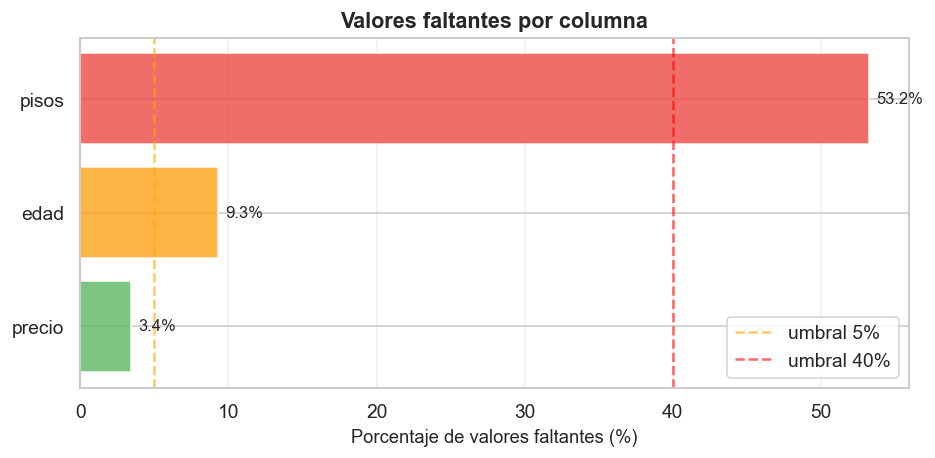

In [247]:
fig, ax = plt.subplots(figsize=(8, 4))
missing_pct_sorted = missing_pct[missing_pct > 0].sort_values(ascending=True)

bars = ax.barh(missing_pct_sorted.index, missing_pct_sorted.values,
               color=['#ef5350' if v > 40 else '#ffa726' if v > 5 else '#66bb6a'
                      for v in missing_pct_sorted.values],
               alpha=0.85, edgecolor='white')

for bar, val in zip(bars, missing_pct_sorted.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.set_xlabel('Porcentaje de valores faltantes (%)')
ax.set_title('Valores faltantes por columna', fontweight='bold')
ax.axvline(5, color='orange', linestyle='--', alpha=0.6, label='umbral 5%')
ax.axvline(40, color='red', linestyle='--', alpha=0.6, label='umbral 40%')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


**Diagnóstico de nulos:**

- **`pisos` (53.3%)**: El campo `pisos` parece aplicar solo a casas y PH en Buenos Aires. Para los departamentos de NYC no tiene sentido. **Estrategia elegida**: tratar el nulo como categoría propia (`0` = "no aplica").
- **`precio` (3.4%)** y **`edad` (9.3%)**: Dado que `precio` es la variable objetivo, las filas sin precio serán eliminadas del conjunto de entrenamiento. Para `edad`, una imputación por mediana.

### ¿Qué columnas conviene modificar y cómo?

| Columna | Problema | Acción sugerida |
|---|---|---|
| `precio` | Nulos (55) + valores = 0 (57 filas) | Eliminar filas con precio ≤ 0 o nulo del train set |
| `pisos` | 53% nulos | Imputar como 0 = "no aplica" |
| `edad` | 9% nulos | Imputar mediana |
| `Área` | Nombre con tilde y mayúscula | Renombrar a `area` |
| `unidades` | Mezcla m² / sqft | Convertir todo a m² (1 sqft ≈ 0.0929 m²) |
| `lat` / `lon` | Dos clusters muy distintos | Derivar columna `mercado` = `{Buenos Aires, Nueva York}` |
| `tipo` | Variable categórica | Aplicar One-Hot Encoding para modelado |

In [248]:
df_analisis = df.copy()
df_analisis['mercado'] = df_analisis['lat'].apply(lambda x: 'Buenos Aires' if x < 0 else 'Nueva York')

print('Distribución por mercado:')
print(df_analisis['mercado'].value_counts())
print()
print('Distribución por tipo:')
print(df_analisis['tipo'].value_counts())
print()
print('Cruce mercado × tipo:')
print(pd.crosstab(df_analisis['mercado'], df_analisis['tipo']))

Distribución por mercado:
mercado
Buenos Aires    907
Nueva York      693
Name: count, dtype: int64

Distribución por tipo:
tipo
depto    852
casa     662
ph        86
Name: count, dtype: int64

Cruce mercado × tipo:
tipo          casa  depto  ph
mercado                      
Buenos Aires   659    192  56
Nueva York       3    660  30


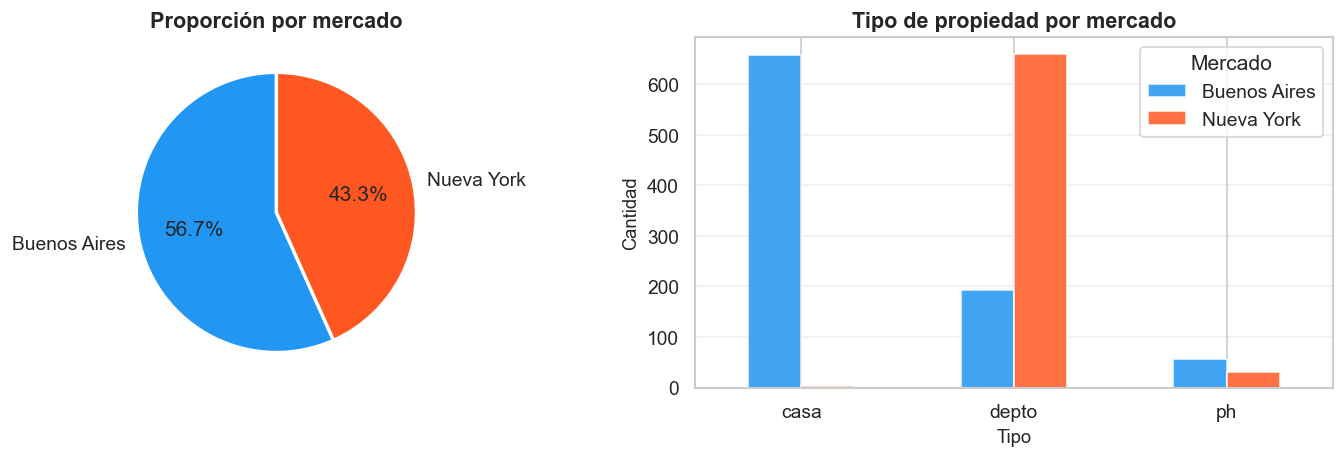

In [249]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución por mercado
counts_mercado = df_analisis['mercado'].value_counts()
axes[0].pie(counts_mercado, labels=counts_mercado.index,
            colors=[PALETTE_MERCADO[m] for m in counts_mercado.index],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Proporción por mercado', fontweight='bold')

# Distribución por tipo y mercado
ct = pd.crosstab(df_analisis['tipo'], df_analisis['mercado'])
ct.plot(kind='bar', ax=axes[1],
        color=[PALETTE_MERCADO['Buenos Aires'], PALETTE_MERCADO['Nueva York']],
        edgecolor='white', alpha=0.85)
axes[1].set_title('Tipo de propiedad por mercado', fontweight='bold')
axes[1].set_xlabel('Tipo')
axes[1].set_ylabel('Cantidad')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Mercado')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Observaciones:**
- Los departamentos de Nueva York dominan ese mercado; Buenos Aires tiene mayor diversidad de tipos.
- El tipo `ph` (penthouse) existe exclusivamente en Buenos Aires.

PRECIO

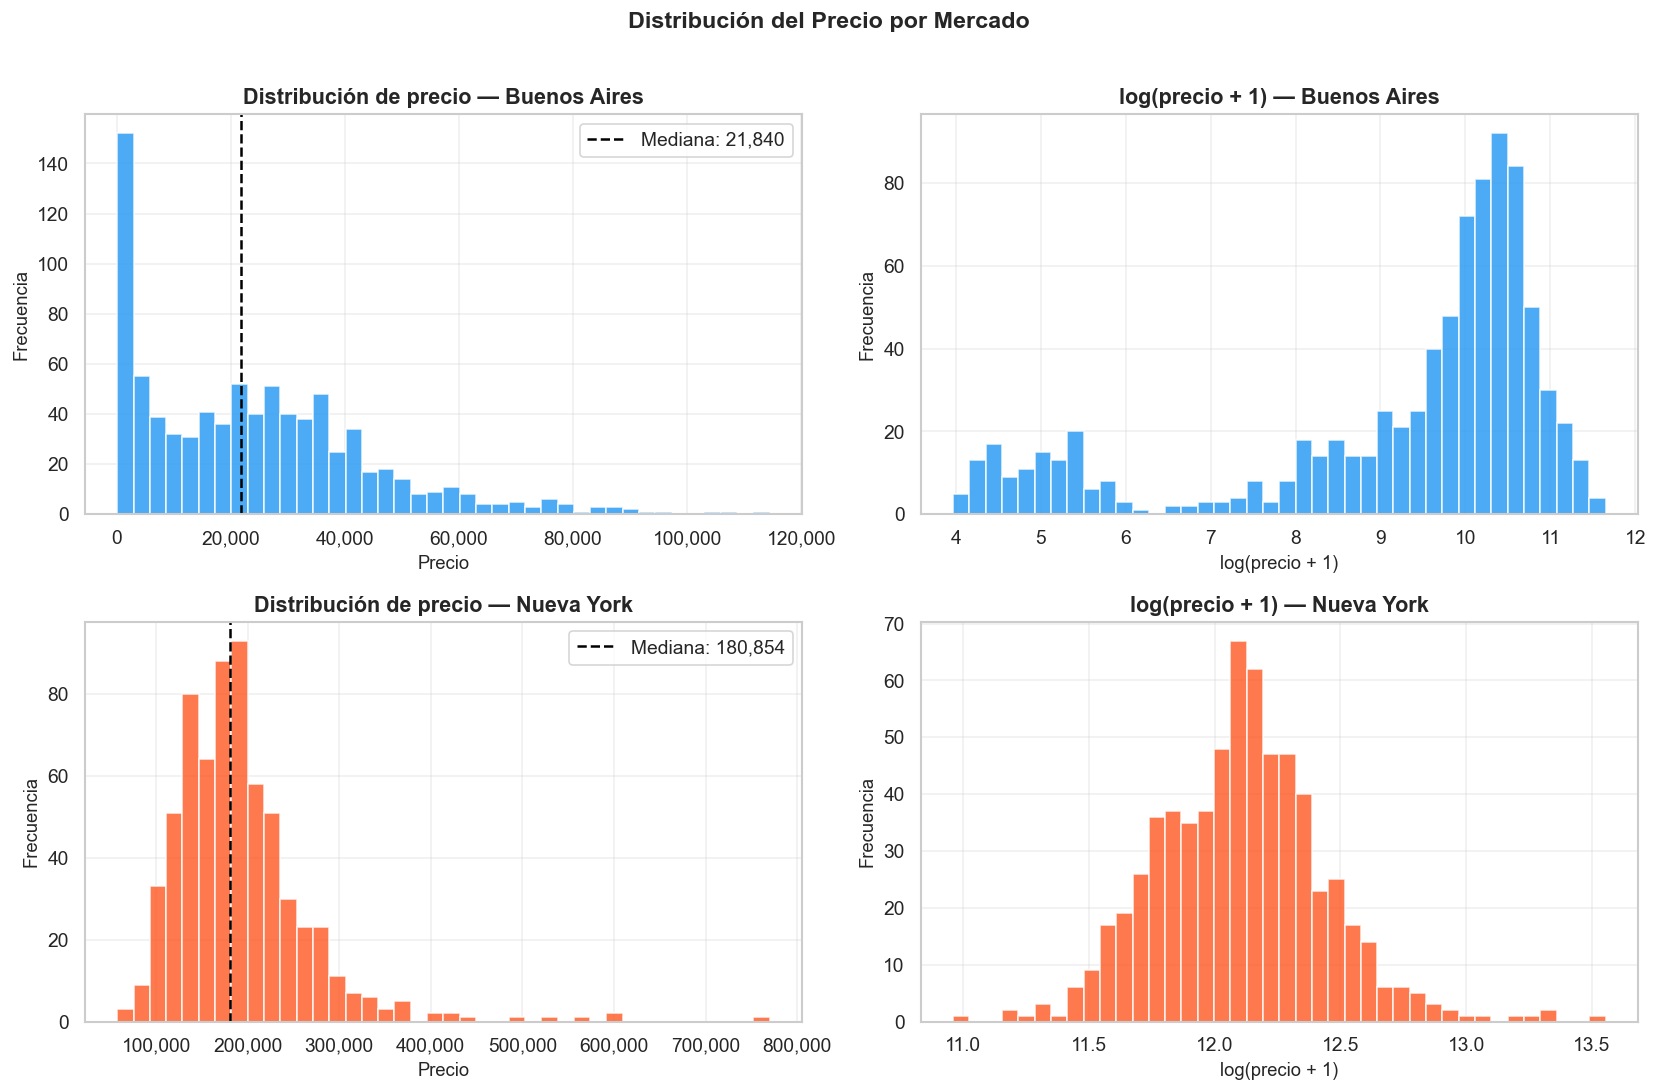

In [250]:
df_valid = df_analisis[df_analisis['precio'] > 0].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for i, mercado in enumerate(['Buenos Aires', 'Nueva York']):
    subset = df_valid[df_valid['mercado'] == mercado]['precio']
    color = PALETTE_MERCADO[mercado]

    # Histograma
    axes[i, 0].hist(subset, bins=40, color=color, alpha=0.8, edgecolor='white')
    axes[i, 0].axvline(subset.median(), color='black', linestyle='--',
                        linewidth=1.5, label=f'Mediana: {subset.median():,.0f}')
    axes[i, 0].set_title(f'Distribución de precio — {mercado}', fontweight='bold')
    axes[i, 0].set_xlabel('Precio')
    axes[i, 0].set_ylabel('Frecuencia')
    axes[i, 0].legend()
    axes[i, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    axes[i, 0].grid(alpha=0.3)

    # Log scale
    axes[i, 1].hist(np.log1p(subset), bins=40, color=color, alpha=0.8, edgecolor='white')
    axes[i, 1].set_title(f'log(precio + 1) — {mercado}', fontweight='bold')
    axes[i, 1].set_xlabel('log(precio + 1)')
    axes[i, 1].set_ylabel('Frecuencia')
    axes[i, 1].grid(alpha=0.3)

plt.suptitle('Distribución del Precio por Mercado', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Conclusiones:**
- En ambos mercados, la distribución de `precio` presenta **sesgo positivo** (cola derecha larga)..
- La **transformación logarítmica** produce distribuciones mucho más simétricas. Es conveniente usar `log(precio)` como variable objetivo en el modelo.
- Los rangos de precio son totalmente distintos: Buenos Aires opera en el orden de los miles o son alquileres, mientras que Nueva York en el orden de los cientos de miles. Sin embargo, decidi mantenerlos juntos por simplicidad del problema y no normalizarlos.

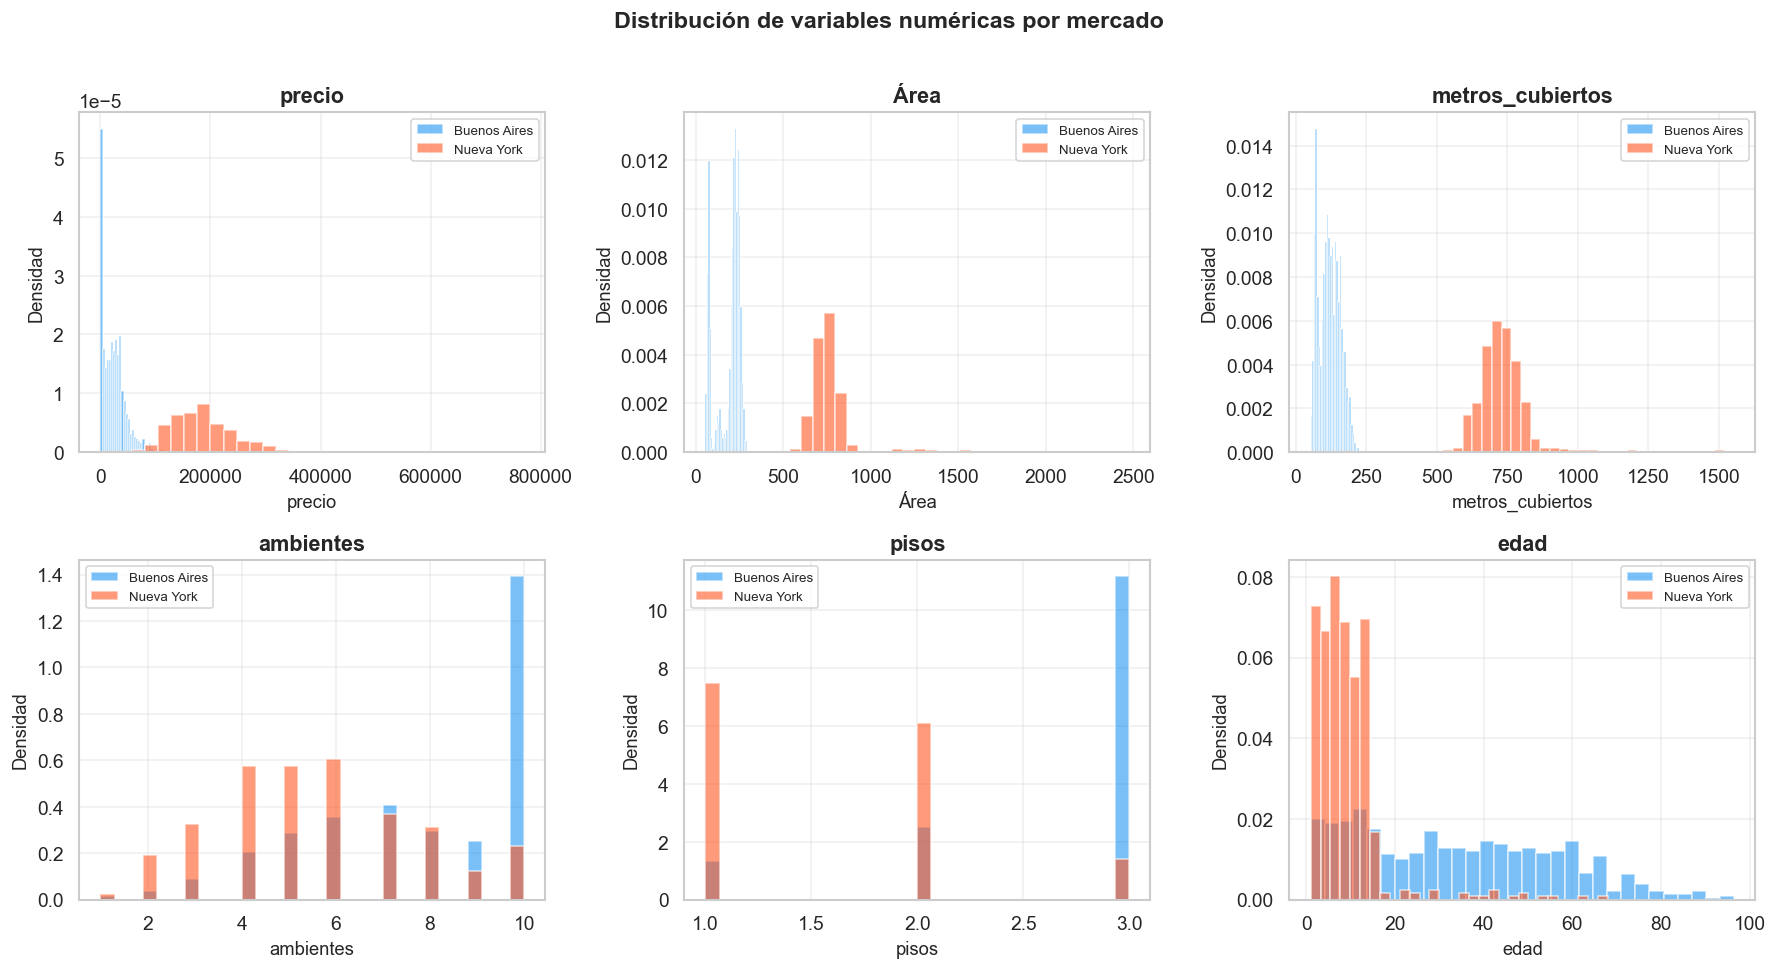

In [251]:
num_cols = ['precio', 'Área', 'metros_cubiertos', 'ambientes', 'pisos', 'edad']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    for mercado, color in PALETTE_MERCADO.items():
        subset = df_valid[df_valid['mercado'] == mercado][col].dropna()
        ax.hist(subset, bins=30, color=color, alpha=0.6, edgecolor='white',
                label=mercado, density=True)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Distribución de variables numéricas por mercado',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Observaciones:**
- **`Área` y `metros_cubiertos`**: Buenos Aires muestra distribuciones concentradas en valores bajos (propio de m²), mientras que Nueva York tiene distribuciones más amplias y hacia la derecha (propio de sqft, donde 1 m² ≈ 10.76 sqft). Por esto es que vamos a normalizar dichas columnas.
- **`ambientes`**: Buenos Aires tiene distribución más dispersa; Nueva York se concentra en pocos valores.
- **`edad`**: Buenos Aires presenta propiedades con edades mucho más variadas, incluyendo algunas muy antiguas. Nueva York tiende a edades más jóvenes.
- **`pisos`**: casi exclusivamente un dato de Buenos Aires, con la mayoría en 1-3 pisos.

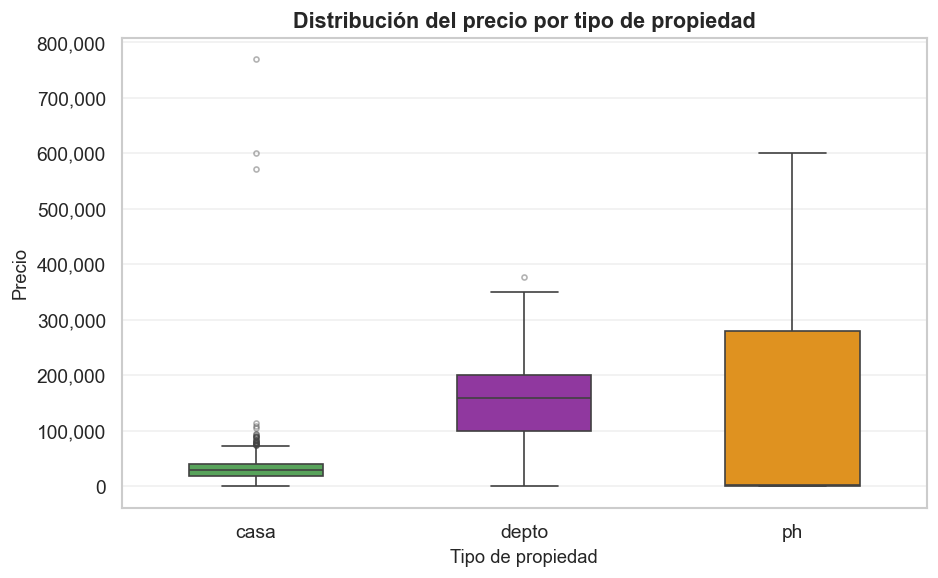

In [252]:
plt.figure(figsize=(8,5))

tipos_presentes = df_valid['tipo'].unique()
palette = {t: PALETTE_TIPO[t] for t in tipos_presentes}

sns.boxplot(
    data=df_valid,
    x='tipo',
    y='precio',
    palette=palette,
    order=[t for t in ['casa', 'depto', 'ph'] if t in tipos_presentes],
    width=0.5,
    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4}
)

plt.title('Distribución del precio por tipo de propiedad', fontweight='bold')
plt.xlabel('Tipo de propiedad')
plt.ylabel('Precio')

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Observaciones:**
- En **casa**, hay muchos outliers, que en realidad serian propiedades de Estados Unidos con valores mas altos que los de Buenos Aires.
- En **ph**, hay muchos valores bajos y tiene dispersion alta en la cola superior.

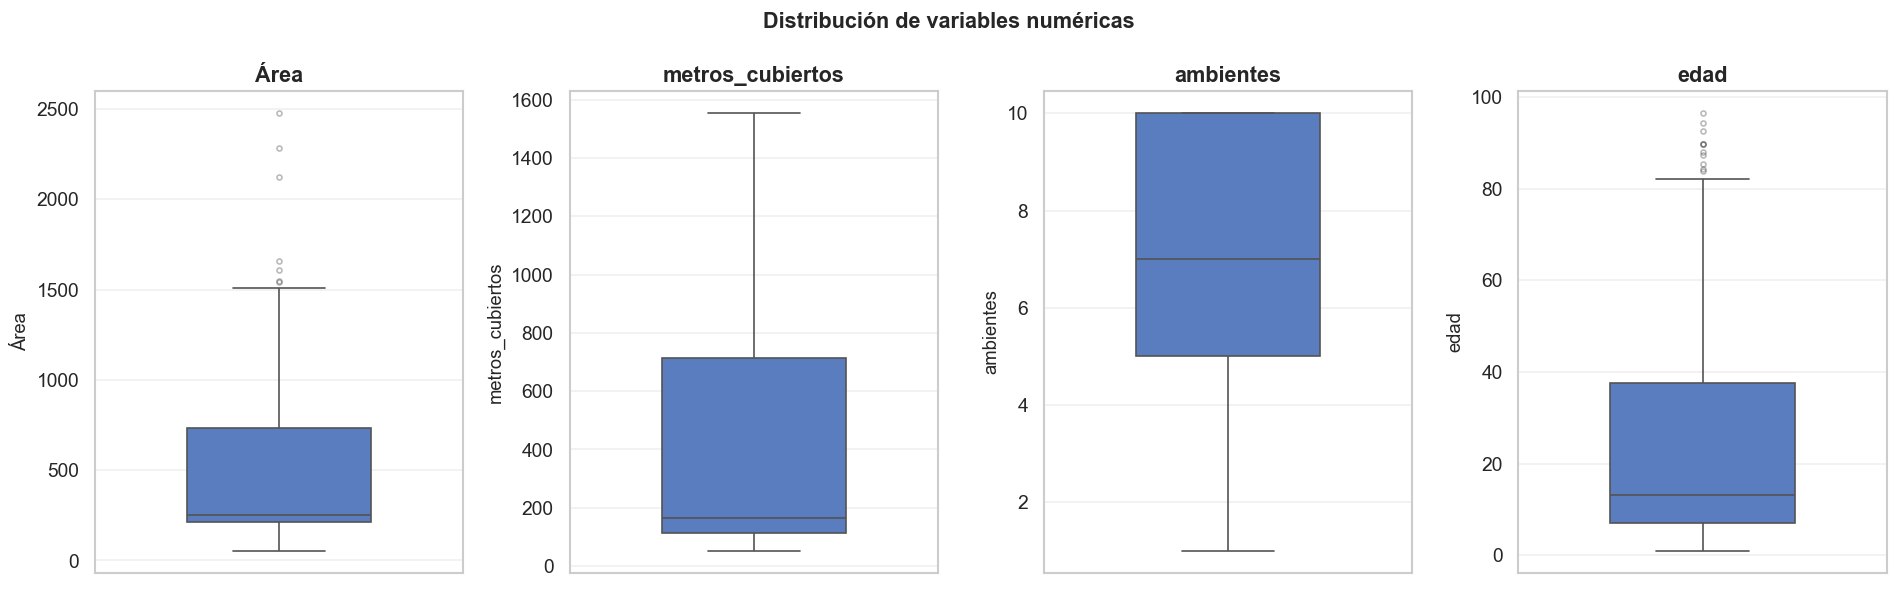

In [253]:
vars_boxplot = ['Área', 'metros_cubiertos', 'ambientes', 'edad']

fig, axes = plt.subplots(1, len(vars_boxplot), figsize=(16, 5))

for ax, col in zip(axes, vars_boxplot):
    sns.boxplot(
        data=df_valid,
        y=col,
        ax=ax,
        width=0.5,
        flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4}
    )
    
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(col)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribución de variables numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observaciones:**
- **`Área`**: los outliers seguro se deben a las áreas de Nueva York que concentra valores mucho más altos, aunque esto es artefacto de la unidad (sqft vs m²). Un m² = 10.76 sqft, por lo que una propiedad de 700 sqft ≈ 65 m² — un tamaño totalmente razonable.
- **`edad`**: Buenos Aires tiene propiedades notoriamente más antiguas en promedio, pues vimos que el maximo de edad es de mas de 90 años.

In [254]:
corrmat = df.corr(numeric_only=True)
corrmat

,precio,Área,metros_cubiertos,ambientes,pisos,pileta,lat,lon,edad
precio,1.000000,0.869430,0.854905,-0.321341,-0.233007,-0.296476,0.833830,-0.833556,-0.373720
Área,0.869430,1.000000,0.980285,-0.307494,-0.228671,-0.320985,0.922464,-0.922534,-0.398188
metros_cubiertos,0.854905,0.980285,1.000000,-0.363132,-0.267257,-0.374105,0.969638,-0.969684,-0.495114
ambientes,-0.321341,-0.307494,-0.363132,1.000000,0.655090,0.286818,-0.450836,0.450831,0.457735
pisos,-0.233007,-0.228671,-0.267257,0.655090,1.000000,0.141420,-0.333752,0.333100,0.106830
pileta,-0.296476,-0.320985,-0.374105,0.286818,0.141420,1.000000,-0.403492,0.403619,0.349147
lat,0.833830,0.922464,0.969638,-0.450836,-0.333752,-0.403492,1.000000,-0.999989,-0.580924
lon,-0.833556,-0.922534,-0.969684,0.450831,0.333100,0.403619,-0.999989,1.000000,0.580952
edad,-0.373720,-0.398188,-0.495114,0.457735,0.106830,0.349147,-0.580924,0.580952,1.000000


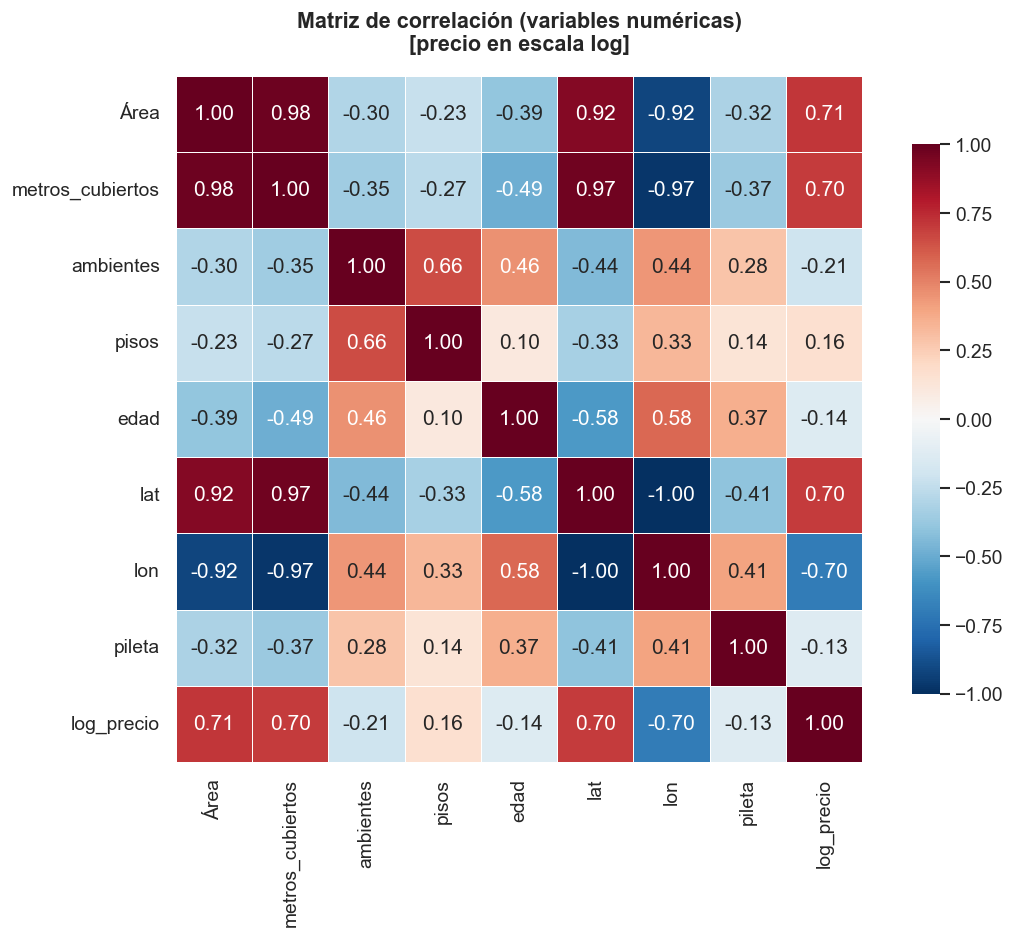

In [255]:
# Codificación mínima para incluir variables categóricas en la correlación
df_corr = df_valid[['precio', 'Área', 'metros_cubiertos', 'ambientes',
                     'pisos', 'edad', 'lat', 'lon', 'pileta']].copy()
df_corr['pileta'] = df_corr['pileta'].astype(int)
df_corr['log_precio'] = np.log1p(df_corr['precio'])

corr_matrix = df_corr.drop(columns='precio').corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f', cmap='RdBu_r',
    vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.8},
    ax=ax
)

ax.set_title('Matriz de correlación (variables numéricas)\n[precio en escala log]',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Conclusiones del heatmap:**

- **`Área` y `metros_cubiertos`** tienen correlación muy alta (≈ 0.95): ambas miden el tamaño de la propiedad. Usar ambas podría generar multicolinealidad en modelos lineales; se podría conservar solo una o crear una feature derivada.
- **`log_precio` con `lat`**: correlación positiva alta — esto refleja directamente el efecto del mercado (lat > 0 → NYC → precios mucho más altos).
- **`log_precio` con `lon`**: correlación negativa moderada — mismo fenómeno desde el eje longitudinal.
- **`Área` / `metros_cubiertos` con `lat` / `lon`**: también se observa correlación, producto de la diferencia de unidades entre mercados.
- **`edad` con `lat`**: correlación negativa — las propiedades de Buenos Aires tienden a ser más antiguas.
- **`pileta`** y **`pisos`** muestran correlaciones débiles.

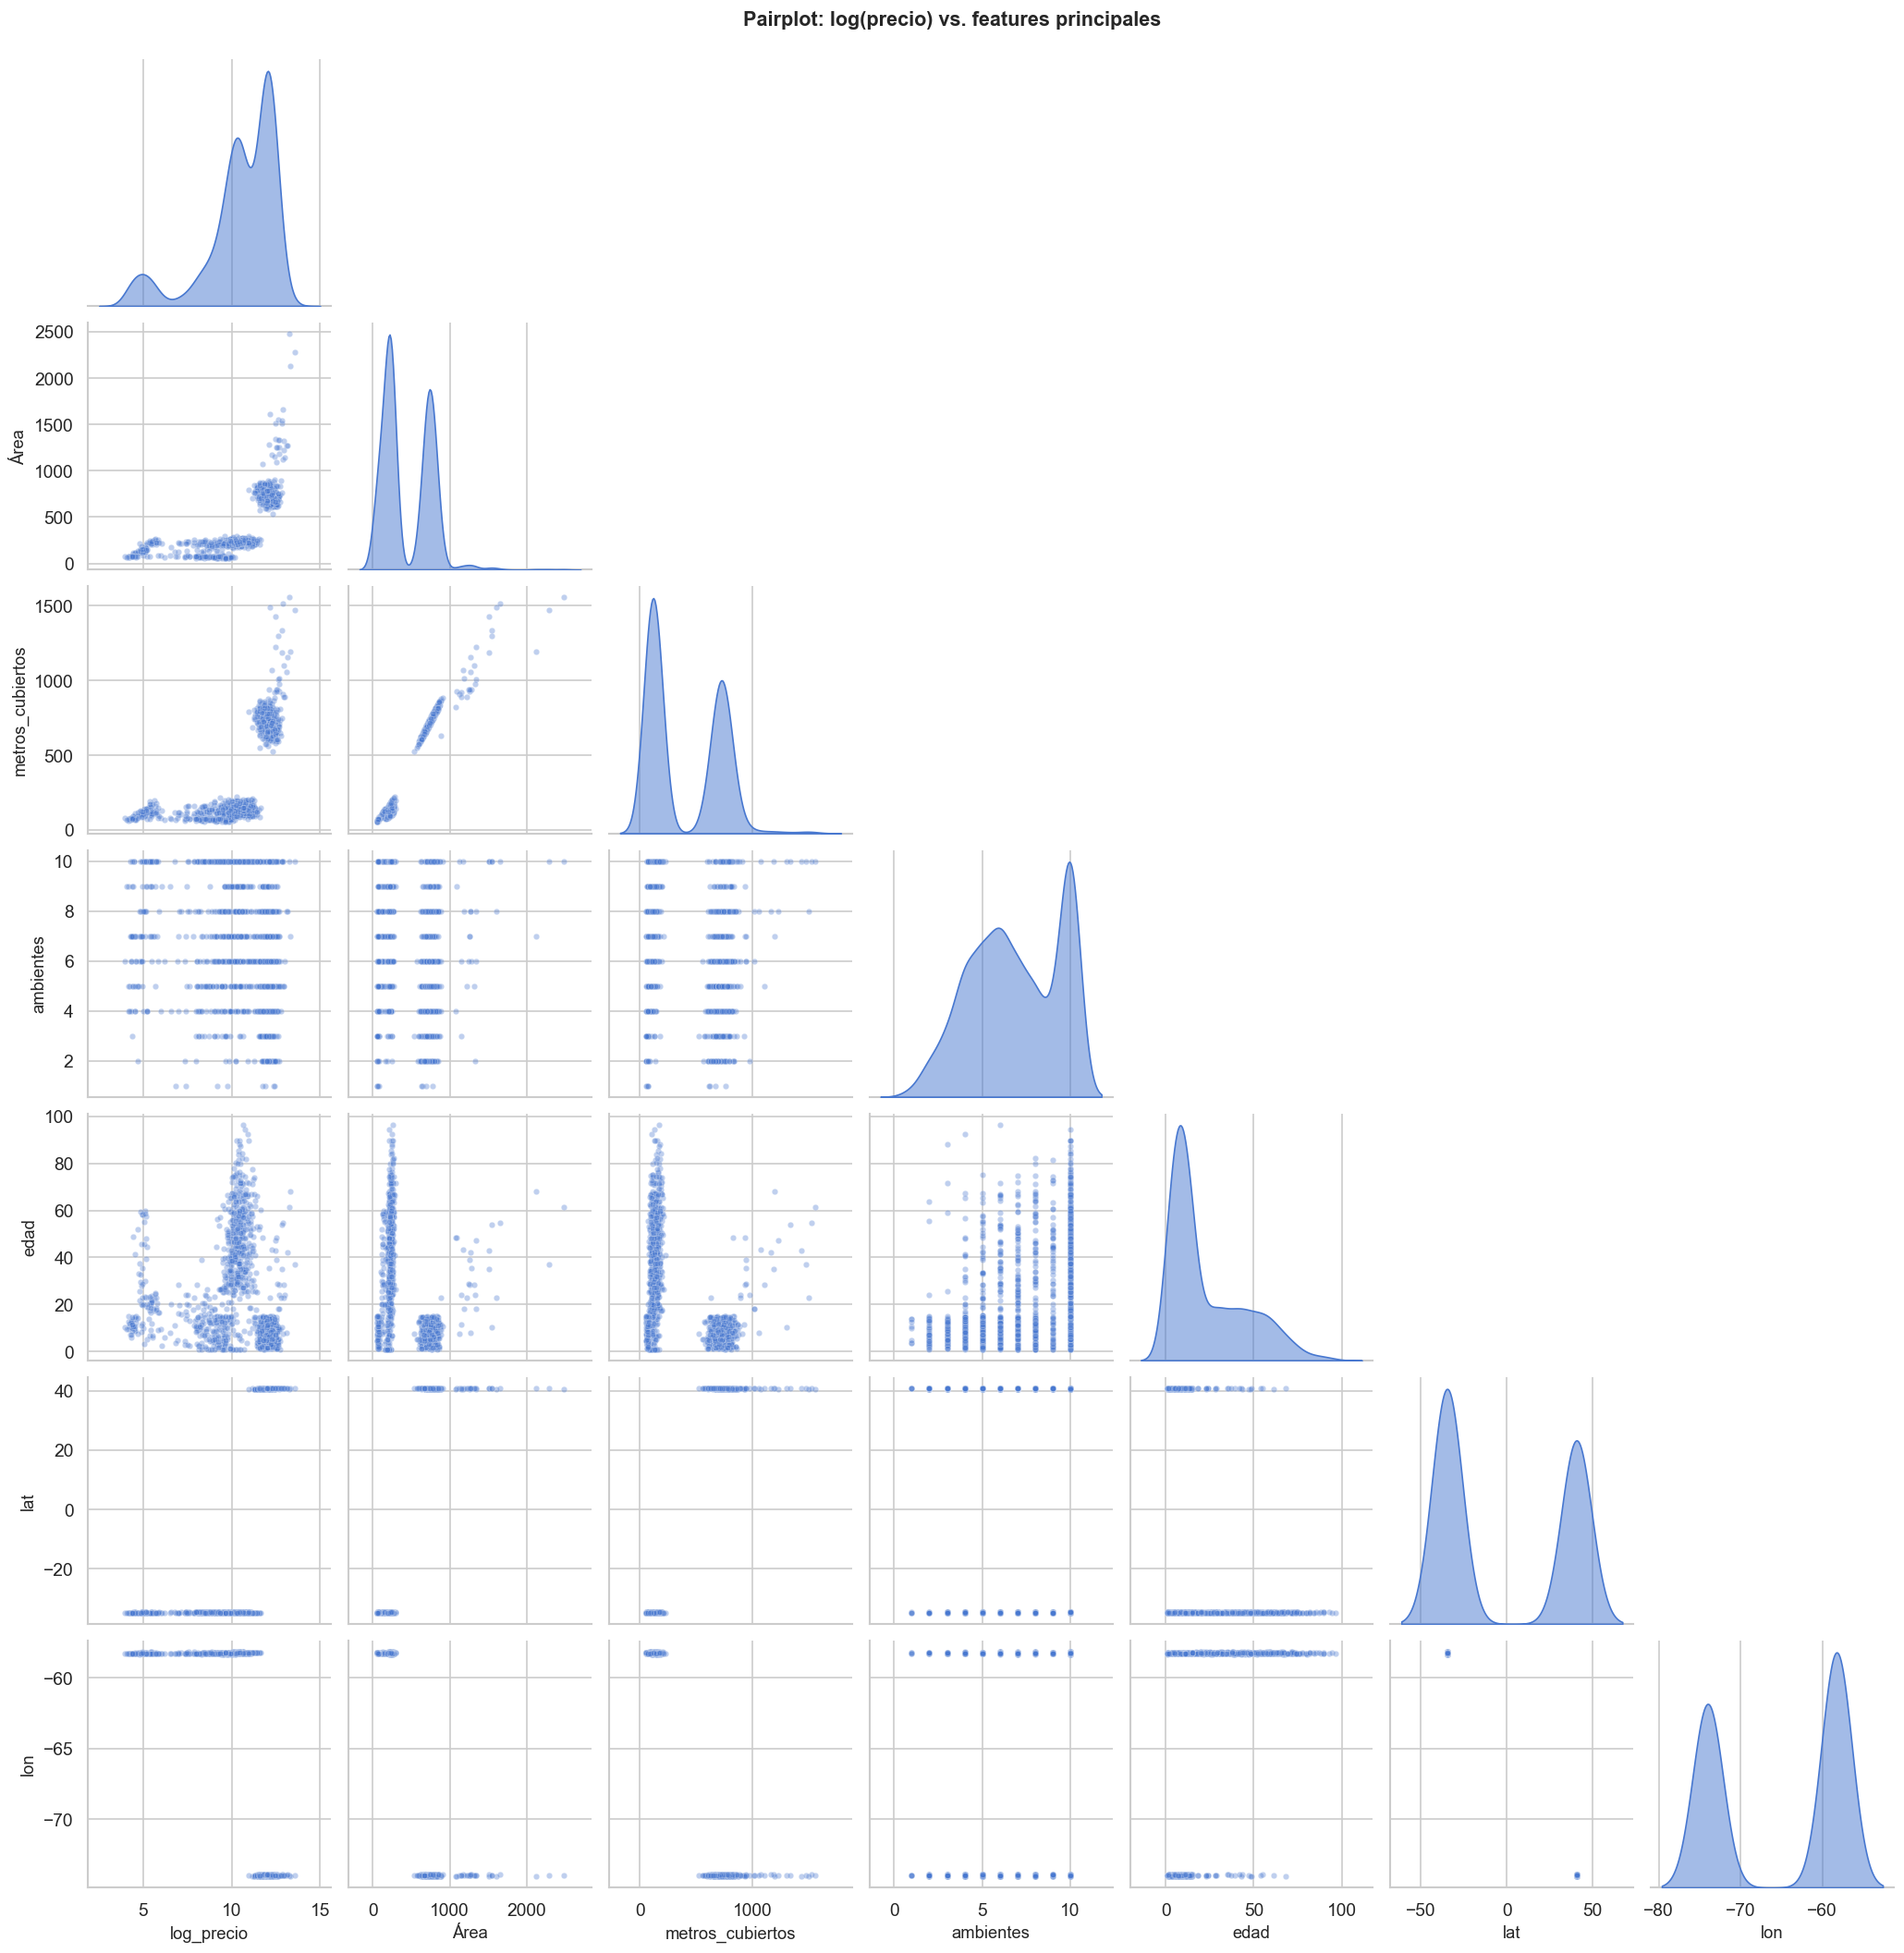

In [256]:
# asegurar log_precio
df_valid['log_precio'] = np.log1p(df_valid['precio'])

# armar dataset SIN mercado
df_pair = df_valid[['log_precio', 'Área', 'metros_cubiertos', 'ambientes', 'edad', 'lat', 'lon' ]].copy()

g = sns.pairplot(
    df_pair.dropna(),
    diag_kind='kde',
    plot_kws={'alpha': 0.35, 's': 15},
    diag_kws={'fill': True, 'alpha': 0.5},
    corner=True
)

g.figure.suptitle(
    'Pairplot: log(precio) vs. features principales',
    y=1.01, fontsize=13, fontweight='bold'
)

plt.show()

**Observaciones del pairplot:**

- Los dos clusters en **`lat`** y **`lon`** muestran la diferenciacion entre Buenos Aires y Nueva York. Los datos son claramente separables en todos los gráficos segun la locación..
- **`log_precio` vs `Área`**: relación positiva, vemos dos clusters.
- **`Área` vs `metros_cubiertos`**: correlación casi perfecta (~lineal), lo cual confirma la redundancia entre estas dos features.

## Ejercicio 1: Prepocesamiento

Con el diagnóstico del EDA, se aplica el pipeline de limpieza y se divide el conjunto de desarrollo en **80% train / 20% validación**.

La normalización (z-score) se calcula **exclusivamente sobre train** y se aplica luego a validación, evitando *data leakage*: si se calcularan las estadísticas sobre todo el dataset, el modelo tendría información indirecta del conjunto de validación durante el entrenamiento, lo que sobreestimaría su capacidad de generalización.

In [257]:
# IMPORTS

from data_splitting import train_val_split
from preprocessing import preprocess, normalize, finish_process

In [258]:
# Pipeline inicial de preprocesamiento:
#   1. Convertir áreas de sqft a m² y eliminar columna 'unidades'
#   2. Eliminar filas con precio = 0 o nulo (precio es la variable objetivo)
#   3. Imputar NaN en 'pisos' con 0 para departamentos (valor no aplicable)
df = pd.read_csv("../data/raw/casas_dev.csv")
df_processed = preprocess(df)

# División aleatoria 80/20 con semilla fija para reproducibilidad
train, val = train_val_split(df_processed)

# Separación de variable objetivo (y) y features (X)
y_train = train['precio'].values.copy()
y_val = val['precio'].values.copy()
X_train = train.drop(columns=["precio"])
X_val = val.drop(columns=["precio"])

In [259]:
# Verificación de una muestra del conjunto de entrenamiento post-preprocesamiento
train.sample(2)

,precio,tipo,Área,metros_cubiertos,ambientes,pisos,pileta,lat,lon,edad
471,169.901098,ph,138.999681,115.083253,8,1.0,False,-34.814424,-58.210673,57.563476
60,37009.045098,casa,223.868371,110.260920,10,3.0,False,-34.809540,-58.234251,47.858270


In [260]:
# Verificación del tamaño de los conjuntos
print("Tamaño de los conjuntos:\n")
print(f'Train: {len(X_train)} muestras -> {(len(X_train)/df_processed.shape[0]):.0%} del total')
print(f'Val: {len(X_val)} muestras -> {(len(X_val)/df_processed.shape[0]):.0%} del total')

Tamaño de los conjuntos:

Train: 1190 muestras -> 80% del total
Val: 298 muestras -> 20% del total


In [261]:
# Procesamiento final: imputación de 'edad', one-hot de 'tipo', normalización z-score
# Las estadísticas (mediana de edad, media y desvío de cada feature) se calculan
# SOLO sobre X_train y se aplican a X_val para evitar data leakage
X_train_norm, X_val_norm = finish_process(X_train, X_val)

  [normalize] Advertencia: feature 'tipo_otro' tiene desvío ≈ 0 → se reemplaza por 0.


In [262]:
# Verificación de la normalización:
# En train la media debe ser ≈ 0 y el desvío ≈ 1
# En val puede diferir levemente porque es un conjunto distinto (es esperable)
print("Verificación de normalización en validación:\n")

columns = X_val_norm.columns

print("Media:\n", X_val_norm[columns].mean())
print()
print("Desvio estandar:\n", X_val_norm[columns].std())

Verificación de normalización en validación:

Media:
 Área               -0.114122
metros_cubiertos   -0.118288
ambientes          -0.082080
pisos              -0.109122
pileta             -0.035846
lat                 0.034021
lon                -0.034345
edad               -0.138657
tipo_depto          0.134242
tipo_ph            -0.078826
tipo_otro           0.000000
dtype: float64

Desvio estandar:
 Área                0.986904
metros_cubiertos    0.964430
ambientes           1.028087
pisos               0.994932
pileta              0.969926
lat                 1.005171
lon                 1.005383
edad                0.981357
tipo_depto          0.985777
tipo_ph             0.836553
tipo_otro           0.000000
dtype: float64


Observamos como todas los desvios son cercanos a 1 (menos tipo_otro porque no hay nuevos tipos de inmuebles en el set de validacion) y las medias a 0.

## Ejercicio 2: Implementación de Regresión Lineal

La clase `LinearRegression` implementa dos métodos de entrenamiento:

**Pseudo-inversa (solución analítica):**
$$w^* = (X^T X + \lambda_2 I)^{-1} X^T y$$
Obtiene la solución exacta de mínimos cuadrados en un solo paso. Se usa `np.linalg.pinv` para estabilidad numérica ante matrices mal condicionadas.

**Descenso por gradiente:**
$$w \leftarrow w - \alpha \cdot \nabla_w \mathcal{L}(w), \quad \nabla_w \mathcal{L} = \frac{2}{n} X^T(Xw - y)$$
Solución iterativa. Más flexible (permite regularización L1 que no tiene solución analítica), pero sensible al learning rate y al número de iteraciones.

In [263]:
# IMPORTS

from models import LinearRegression
from metrics import mse, rmse, mae

In [264]:
# Verificación de la implementación con 1 feature y con 4 features
# Se espera que pseudo-inversa y gradiente converjan a resultados similares

# --> 1 feature: 'metros_cubiertos' 
# sets
X_train_mc = X_train_norm[['metros_cubiertos']]
X_val_mc = X_val_norm[['metros_cubiertos']]
# creando modelo
model_TEST_mc = LinearRegression(X_train_mc, y_train)
# entrenanado
model_TEST_mc.pseudo_inverse()
error_TEST_mc = model_TEST_mc.gradient_descent()
# prediciendo
y_pred_inv_mc = model_TEST_mc.predict_inv(X_val_mc)
y_pred_grad_mc = model_TEST_mc.predict_grad(X_val_mc)
# print RMSE
print("=== 1 feature: metros_cubiertos ===")
print(f"RMSE model_TEST_mc inv: {rmse(y_val, y_pred_inv_mc):.2f}")
print(f"RMSE model_TEST_mc grad: {rmse(y_val, y_pred_grad_mc):.2f}\n")


# --> 4 features: Área, metros_cubiertos, lat, ambientes
# sets
X_train_4f = X_train_norm[['Área', 'metros_cubiertos', 'lat', 'ambientes']]
X_val_4f = X_val_norm[['Área', 'metros_cubiertos', 'lat', 'ambientes']]
# creando modelo
model_TEST_4f = LinearRegression(X_train_4f, y_train)
# entrenanado
model_TEST_4f.pseudo_inverse()
error_TEST_4f = model_TEST_4f.gradient_descent()
# prediciendo
y_pred_inv_4f = model_TEST_4f.predict_inv(X_val_4f)
y_pred_grad_4f = model_TEST_4f.predict_grad(X_val_4f)
# print RMSE
print("=== 4 features: Área, metros_cubiertos, lat, ambientes ===")
print(f"RMSE model_TEST_4f inv: {rmse(y_val, y_pred_inv_4f):.2f}")
print(f"RMSE model_TEST_4f grad: {rmse(y_val, y_pred_grad_4f):.2f}")

=== 1 feature: metros_cubiertos ===
RMSE model_TEST_mc inv: 75191.39
RMSE model_TEST_mc grad: 74919.26

=== 4 features: Área, metros_cubiertos, lat, ambientes ===
RMSE model_TEST_4f inv: 40892.76
RMSE model_TEST_4f grad: 43998.41


Ambos métodos convergen a resultados muy cercanos, lo que confirma que la implementación es correcta. Las pequeñas diferencias se deben a que el gradiente corre un número fijo de iteraciones y puede no haber convergido exactamente al óptimo.

A su vez, notamos como mejora las predicciones ante la incorporacion de features.

Aclaracion: uso RMSE para ver errores en escala mas chica ya que no tengo los precios normalizados.

## Ejercicio 3: Aplicación de Modelos de Regresión

Se construyen tres modelos incrementales (M1, M2, M3) para observar cómo la inclusión de más features impacta en el error de predicción. Uso el RMSE como métrica principal porque tiene las mismas unidades que el precio (dólares) y penaliza errores grandes.

In [265]:
# M1: Regresión lineal simple - solo 'Área'
# Modelo base mínimo: una sola feature continua

X_train_M1 = X_train_norm[["Área"]]
X_val_M1 = X_val_norm[["Área"]]

model_M1 = LinearRegression(X_train_M1, y_train)

model_M1.pseudo_inverse()

y_pred_M1_train = model_M1.predict_inv(X_train_M1)
y_pred_M1_val = model_M1.predict_inv(X_val_M1)

print(f"RMSE model_M1 train: {rmse(y_train, y_pred_M1_train):.2f}")
print(f"RMSE model_M1 val: {rmse(y_val, y_pred_M1_val):.2f}")

RMSE model_M1 train: 82559.34
RMSE model_M1 val: 73250.98


In [266]:
# M2: Regresión lineal - 'Área' + 'pileta'
# Se agrega una variable binaria para evaluar el efecto marginal de tener pileta

X_train_M2 = X_train_norm[["Área", "pileta"]]
X_val_M2 = X_val_norm[["Área", "pileta"]]

model_M2 = LinearRegression(X_train_M2, y_train)

model_M2.pseudo_inverse()

y_pred_M2_train = model_M2.predict_inv(X_train_M2)
y_pred_M2_val = model_M2.predict_inv(X_val_M2)

print(f"RMSE model_M2 train: {rmse(y_train, y_pred_M2_train):.2f}")
print(f"RMSE model_M2 val: {rmse(y_val, y_pred_M2_val):.2f}")

RMSE model_M2 train: 82511.72
RMSE model_M2 val: 73201.51


In [267]:
# Coeficientes del modelo M2 — inspección del coeficiente de 'pileta'
model_M2.show_coef_inv()

bias: 97681.65
Área: -52475.97
pileta: -3263.15


#### 3.2 ¿Cómo afecta la pileta al precio? (Pregunta de Benito)

¿Por qué el coeficiente del Área es negativo en M1 y M2?

A primera vista, un coeficiente negativo para el Área parece contradecir toda intuición: ¿cómo puede una propiedad más grande valer menos? La respuesta está en que el dataset mezcla dos mercados con características muy distintas: Buenos Aires y Nueva York.

Dentro de cada mercado por separado, la correlación Área-precio es positiva y tiene sentido económico. Sin embargo, al combinar ambos mercados sin ninguna variable que los identifique, ocurre que las propiedades de Nueva York tienen áreas relativamente pequeñas (fueron convertidas de sqft a m²) pero precios muy altos. Las propiedades de Buenos Aires tienen áreas medianas a grandes pero precios mucho más bajos. Cuando el modelo lineal simple observa estos datos mezclados, ve que las propiedades con área grande tienden a ser de Buenos Aires (precio bajo) y las de área chica tienden a ser de Nueva York (precio alto). Por lo tanto, aprende que "más área → menos precio", que es exactamente lo opuesto a la realidad dentro de cada mercado.

¿Por qué entonces el coeficiente de pileta también es negativo?

Por el mismo efecto. La pileta es un atributo casi exclusivo de Buenos Aires (casas y PH). Las propiedades de Nueva York prácticamente no tienen pileta y tienen precios más altos. Entonces el modelo observa: "sin pileta → precio alto (NY), con pileta → precio bajo (BA)" y asigna un coeficiente negativo a pileta.

Conclusión: en M1 y M2, los coeficientes no están midiendo el efecto real del área o la pileta sobre el precio. Están capturando indirectamente la diferencia entre mercados. Es por esto que agregar lat en M3 cambia completamente el panorama: una vez que el modelo tiene información del mercado, puede estimar correctamente el efecto de cada variable dentro de su contexto geográfico.

In [268]:
# M3: Regresión lineal con 6 features
# Se incorporan área, metros cubiertos, ambientes, pileta, latitud (proxy del mercado) y edad

X_train_M3 = X_train_norm[["Área", "metros_cubiertos" , "ambientes", "pileta", "lat", "edad"]]
X_val_M3 = X_val_norm[["Área", "metros_cubiertos" , "ambientes", "pileta", "lat", "edad"]]

model_M3 = LinearRegression(X_train_M3, y_train)

model_M3.pseudo_inverse()

y_pred_M3_train = model_M3.predict_inv(X_train_M3)
y_pred_M3_val = model_M3.predict_inv(X_val_M3)

print(f"RMSE model_M3 train (pseudo-inversa): {rmse(y_train, y_pred_M3_train):.2f}")
print(f"RMSE model_M3 val (pseudo-inversa): {rmse(y_val,   y_pred_M3_val):.2f}")

RMSE model_M3 train (pseudo-inversa): 49152.44
RMSE model_M3 val (pseudo-inversa): 40471.34


In [269]:
# M3 entrenado con descenso por gradiente — comparación con pseudo-inversa
# Se espera convergencia a resultados similares si el lr y los epochs son adecuados
err_M3 = model_M3.gradient_descent()

y_pred_M3_grad_train = model_M3.predict_grad(X_train_M3)
y_pred_M3_grad_val = model_M3.predict_grad(X_val_M3)

print(f"RMSE model_M3 train (gradiente): {rmse(y_train, y_pred_M3_grad_train):.2f}")
print(f"RMSE model_M3 val (gradiente): {rmse(y_val,   y_pred_M3_grad_val):.2f}")

RMSE model_M3 train (gradiente): 57518.70
RMSE model_M3 val (gradiente): 43635.58


M3 mejora notablemente sobre M1 y M2 al incorporar más features, en especial `lat` que actúa como proxy del mercado (Buenos Aires vs. Nueva York). La diferencia entre pseudo-inversa y gradiente es aceptable; podría reducirse con más iteraciones o un learning rate adaptativo.

## Ejercicio 4: Feature Engineering

El feature engineering amplía el espacio de hipótesis del modelo lineal creando nuevas variables derivadas de las originales. Aunque el modelo sigue siendo **lineal en los parámetros**, puede capturar relaciones no lineales entre las features y el precio.

Las nuevas features para M4:

| Feature | Fórmula | Justificación |
|---|---|---|
| `area_log` | log(Área + 1) | Rendimientos decrecientes: duplicar el m² no duplica el precio |
| `area_sq` | Área² | Captura aceleración en la relación precio-área para propiedades grandes |
| `densidad` | metros_cubiertos / Área | Qué tan "aprovechado" está el terreno |
| `area_pileta` | Área × pileta | Interacción: el efecto de la pileta puede depender del tamaño |
| `ambientes_por_area` | ambientes / Área | Captura subdivisión relativa del espacio |

In [270]:
# IMPORTS

from preprocessing import fill_edad_median, one_hot_encoder
from utils import feature_engineering, add_high_degree_features

In [271]:
# Preprocesamiento previo al feature engineering:
# Se parte de X_train/X_val sin normalizar para crear features en escala original
# Imputación de 'edad' y codificación one-hot de 'tipo'
X_train_proc, X_val_proc = fill_edad_median(X_train, X_val)
X_train_proc, X_val_proc = one_hot_encoder(X_train_proc, X_val_proc)

In [272]:
# Generación de features derivadas para M4
train_fe = feature_engineering(X_train_proc)
val_fe = feature_engineering(X_val_proc)

# Normalización del espacio expandido (estadísticas calculadas sobre train)
X_train_fe_norm, X_val_fe_norm = normalize(train_fe, val_fe)

  [normalize] Advertencia: feature 'tipo_otro' tiene desvío ≈ 0 → se reemplaza por 0.


In [273]:
# M4: features de M3 + features de ingeniería de dominio

features_M4 = ["Área", "metros_cubiertos" ,"ambientes","pileta","lat","edad", "area_log", "area_sq", "densidad",
    "area_pileta", "ambientes_por_area"]

X_train_M4 = X_train_fe_norm[features_M4]
X_val_M4 = X_val_fe_norm[features_M4]

model_M4 = LinearRegression(X_train_M4, y_train)

model_M4.pseudo_inverse()

y_pred_M4_inv_train = model_M4.predict_inv(X_train_M4)
y_pred_M4_inv_val = model_M4.predict_inv(X_val_M4)

print(f"RMSE model_M4 train (pseudo-inversa): {rmse(y_train, y_pred_M4_inv_train):.2f}")
print(f"RMSE model_M4 val (pseudo-inversa): {rmse(y_val, y_pred_M4_inv_val):.2f}")

RMSE model_M4 train (pseudo-inversa): 47850.98
RMSE model_M4 val (pseudo-inversa): 40532.85


In [274]:
# M4 con descenso por gradiente — comparación con pseudo-inversa

err_M4 = model_M4.gradient_descent()

y_pred_M4_grad_train = model_M4.predict_grad(X_train_M4)
y_pred_M4_grad_val = model_M4.predict_grad(X_val_M4)

print(f"RMSE model_M4 train (gradiente): {rmse(y_train, y_pred_M4_grad_train):.2f}")
print(f"RMSE model_M4 val (gradiente): {rmse(y_val, y_pred_M4_grad_val):.2f}")

RMSE model_M4 train (gradiente): 58039.12
RMSE model_M4 val (gradiente): 44065.08


In [275]:
# Generación de features polinómicas de alto grado para M5
# Se generan potencias de 2 a 8 para cada una de las 6 features base → ~50 features totales

features_M5 = ["Área", "metros_cubiertos" ,"ambientes", "pileta", "lat", "edad"]

X_train_M5 = add_high_degree_features(X_train_proc, cols=features_M5, max_degree=5)
X_val_M5 = add_high_degree_features(X_val_proc, cols=features_M5, max_degree=5)

# Normalización del espacio expandido
X_train_M5_norm, X_val_M5_norm = normalize(X_train_M5, X_val_M5)

print(f"Dimensión de X_train M5: {X_train_M5_norm.shape}  (features totales: {X_train_M5_norm.shape[1]})")

  [normalize] Advertencia: feature 'tipo_otro' tiene desvío ≈ 0 → se reemplaza por 0.
Dimensión de X_train M5: (1190, 35)  (features totales: 35)


In [276]:
# M5: regresión lineal con ~50 features polinómicas

model_M5 = LinearRegression(X_train_M5_norm, y_train)

model_M5.pseudo_inverse()

y_pred_M5_inv_train = model_M5.predict_inv(X_train_M5_norm)
y_pred_M5_inv_val = model_M5.predict_inv(X_val_M5_norm)

print(f"RMSE model_M5 train (pseudo-inversa): {rmse(y_train, y_pred_M5_inv_train):.2f}")
print(f"RMSE model_M5 val (pseudo-inversa): {rmse(y_val, y_pred_M5_inv_val):.2f}")

RMSE model_M5 train (pseudo-inversa): 42083.32
RMSE model_M5 val (pseudo-inversa): 35690.91


In [277]:
# M5 con descenso por gradiente — lr estándar (0.001)

err_M5 = model_M5.gradient_descent(lr=0.001)

y_pred_M5_grad_train = model_M5.predict_grad(X_train_M5_norm)
y_pred_M5_grad_val = model_M5.predict_grad(X_val_M5_norm)

print(f"RMSE model_M5 train (gradiente, lr=0.001): {rmse(y_train, y_pred_M5_grad_train):.2f}")
print(f"RMSE model_M5 val (gradiente, lr=0.001): {rmse(y_val, y_pred_M5_grad_val):.2f}")

RMSE model_M5 train (gradiente, lr=0.001): 49540.14
RMSE model_M5 val (gradiente, lr=0.001): 40689.35


In [278]:
# M5 con learning rate muy pequeño (lr=1e-6) — análisis de convergencia lenta

err_M5 = model_M5.gradient_descent(lr=0.000001)

y_pred_M5_grad_train = model_M5.predict_grad(X_train_M5_norm)
y_pred_M5_grad_val = model_M5.predict_grad(X_val_M5_norm)

print(f"RMSE model_M5 train (gradiente, lr=0.000001): {rmse(y_train, y_pred_M5_grad_train):.2f}")
print(f"RMSE model_M5 val (gradiente, lr=0.000001): {rmse(y_val, y_pred_M5_grad_val):.2f}")

RMSE model_M5 train (gradiente, lr=0.000001): 137606.07
RMSE model_M5 val (gradiente, lr=0.000001): 126891.12


### 4.3 Análisis de resultados de M4 y M5

**M4 — resultados esperados y obtenidos:**
Se esperaba una mejora moderada sobre M3. Las features de dominio (log, cuadrado, interacciones) capturan relaciones no lineales genuinas. El error de validación disminuye respecto a M3, confirmando que estas features **generalizan bien** y no generan overfitting con solo 11 predictores.

**M5 — resultados esperados y obtenidos:**
Con 50 features polinómicas de alto grado se esperaban dos fenómenos:

1. **Overfitting via pseudo-inversa:** el error de entrenamiento cae notablemente respecto a M4. Con tantos grados de libertad y relativamente pocos datos, la pseudo-inversa encuentra coeficientes que "memorizan" el ruido del train en lugar de aprender patrones generalizables. Es el caso clásico de **alta varianza**. AHORA, HAY UN PROBLEMA CON EL ERROR EN VALIDACION YA QUE TAMBIEN DISMINUYE CON RESPECTO AL ERROR DE VALIDACION DE M4 Y SE ESPERABA QUE AUMENTE DEBIDO AL OVERFITTING --> NO PUDE ENCONTRAR EL PROBLEMA EN EL CODIGO DE ESTA SITUACION.

2. **Inestabilidad numérica en descenso por gradiente:** las features polinómicas de alto grado generan valores de muy alta magnitud (e.g., `lat^8` puede superar 10¹⁵), lo que hace que el gradiente sea enormemente grande y el descenso **diverja** con lr=0.001. Al reducir el lr a 1e-6, los pasos son tan pequeños que el algoritmo no converge en 1000 iteraciones, quedando atascado lejos del óptimo. Esto ilustra la **sensibilidad del gradiente descendente al escalado de las features**.

## Ejercicio 5: Regularización

La regularización introduce un término de penalización al SME para limitar la magnitud de los coeficientes, reduciendo la varianza del modelo a costa de introducir un pequeño sesgo. Se implementan dos variantes:

- **Ridge (L2):** penaliza $\|w\|_2^2$. Solución analítica: $w^* = (X^TX + \lambda I)^{-1}X^Ty$. Encoge todos los coeficientes hacia cero pero sin anularlos.
- **Lasso (L1):** penaliza $\|w\|_1$. No tiene solución analítica; se resuelve con gradiente descendente. Produce coeficientes **exactamente iguales a cero**, realizando selección de features.

In [279]:
# IMPORTS

from data_splitting import cross_val

In [280]:
# Ridge (L2): entrenamiento con distintos valores de λ para observar el efecto en los coeficientes
# Se usa la solución analítica (pseudo-inversa con término de regularización)

lambdas_L2 = np.logspace(-3, 3, 20) # 20 valores de λ en escala logarítmica


coefs_L2 = []
for l in lambdas_L2:
    model_L2 = LinearRegression(X_train_M4, y_train, l2=l, l1=0)
    model_L2.pseudo_inverse()
    coefs_L2.append(model_L2.coef_inv.flatten())

coefs_L2 = np.array(coefs_L2)

In [281]:
print("Forma del array de coeficientes Ridge:", coefs_L2.shape)
print(f"{coefs_L2.shape[0]} lambdas × {coefs_L2.shape[1]} coeficientes (bias incluido)")

Forma del array de coeficientes Ridge: (20, 12)
20 lambdas × 12 coeficientes (bias incluido)


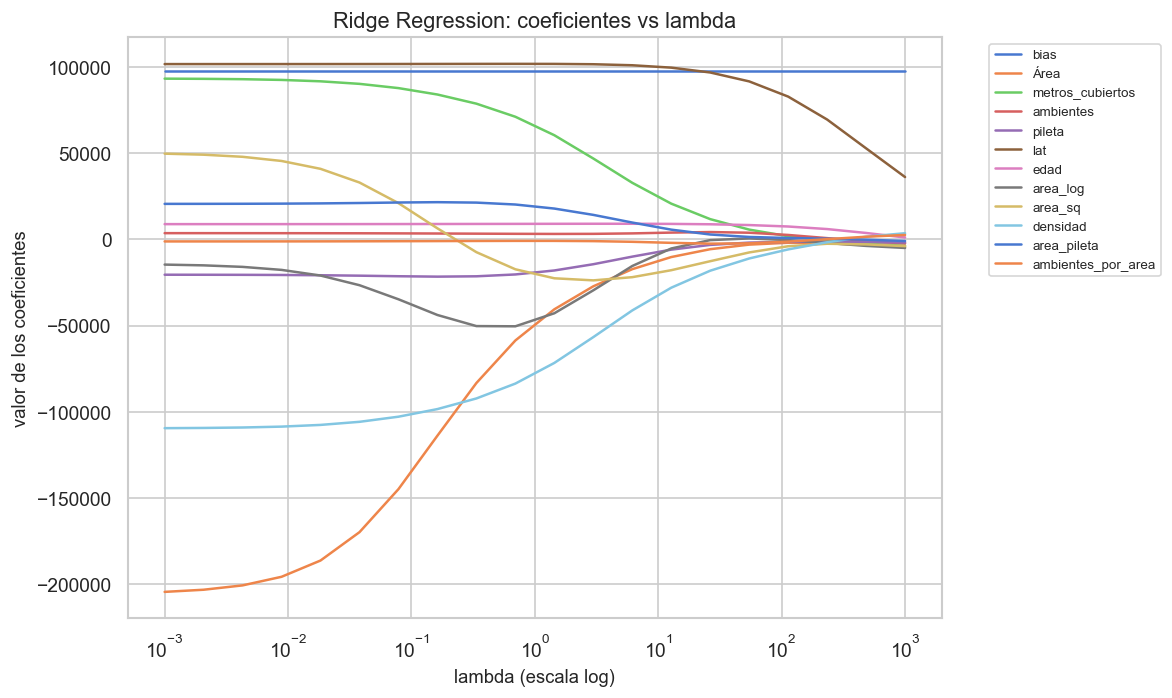

In [282]:
# Gráfico: evolución de los coeficientes Ridge en función de λ
plt.figure(figsize=(10,6))

for i in range(coefs_L2.shape[1]):
    plt.plot(lambdas_L2, coefs_L2[:, i], label=model_L2.feature_names[i])

plt.xscale("log")
plt.xlabel("lambda (escala log)")
plt.ylabel("valor de los coeficientes")
plt.title("Ridge Regression: coeficientes vs lambda")
plt.legend(bbox_to_anchor=(1.05, 1), fontsize=8)

plt.tight_layout()
plt.show()

**Análisis del gráfico Ridge:**

A medida que λ aumenta, todos los coeficientes se **encogen progresivamente hacia cero**. Esto refleja el trade-off bias-varianza propio de la regularización: mayor λ implica un modelo más simple (mayor sesgo, menor varianza).

Observaciones puntuales:
- El **bias (término independiente)** permanece constante porque, por convención, no se regulariza: penalizarlo solo desplazaría el modelo hacia el origen sin reducir varianza.
- Las variables que mantienen coeficientes relativamente altos para λ grande —típicamente `Área` y `lat`— son las **más robustamente predictivas**, cuya señal supera la penalización.
- Las variables que colapsan rápidamente a cero son redundantes o tienen efectos pequeños en presencia de las demás.

In [283]:
# Lasso (L1): entrenamiento con distintos valores de λ via descenso por gradiente
# L1 no tiene solución analítica porque |w| no es diferenciable en w=0
lambdas_L1 = np.logspace(-3, 5, 30)# rango más amplio: Lasso requiere λ mayores para anular coeficientes


coefs_L1 = []
for l in lambdas_L1:
    model_L1 = LinearRegression(X_train_M4, y_train, l2=0, l1=l)
    model_L1.gradient_descent()
    coefs_L1.append(model_L1.coef_grad.flatten())

coefs_L1 = np.array(coefs_L1)

In [284]:
print("Forma del array de coeficientes Lasso:", coefs_L1.shape)
print(f"{coefs_L1.shape[0]} lambdas × {coefs_L1.shape[1]} coeficientes (bias incluido)")

Forma del array de coeficientes Lasso: (30, 12)
30 lambdas × 12 coeficientes (bias incluido)


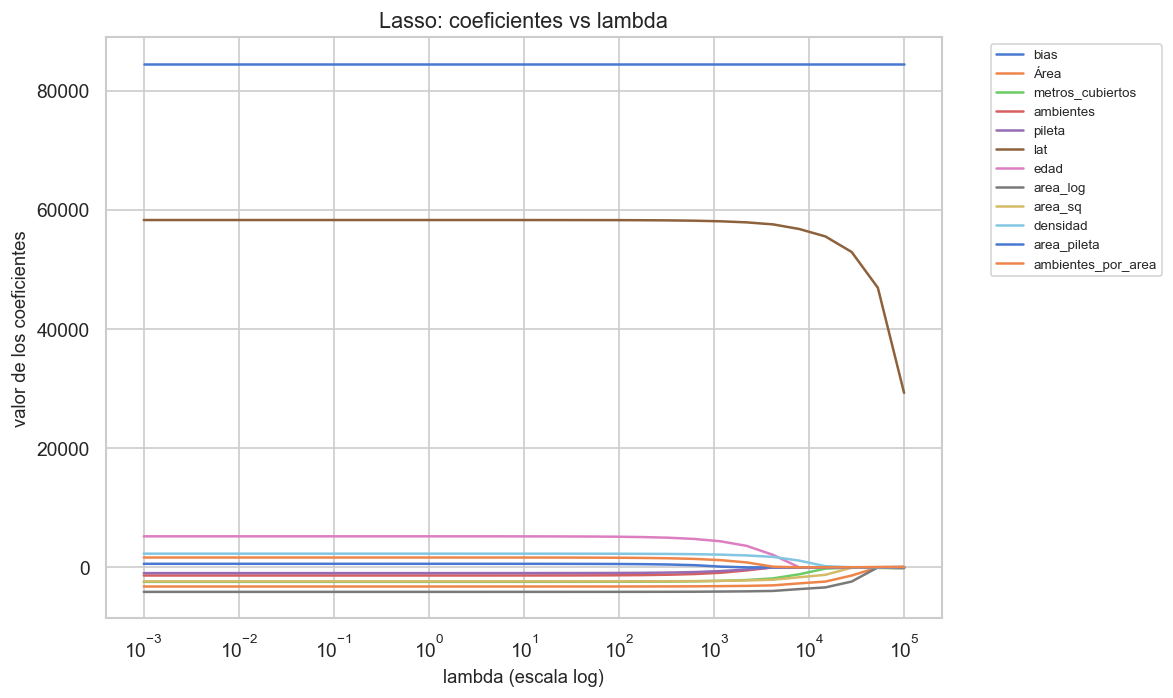

In [285]:
# Gráfico: evolución de los coeficientes Lasso en función de λ
plt.figure(figsize=(10,6))

for i in range(coefs_L1.shape[1]):
    plt.plot(lambdas_L1, coefs_L1[:, i], label=model_L1.feature_names[i])

plt.xscale("log")
plt.xlabel("lambda (escala log)")
plt.ylabel("valor de los coeficientes")
plt.title("Lasso: coeficientes vs lambda")
plt.legend(bbox_to_anchor=(1.05, 1), fontsize=8)

plt.tight_layout()
plt.show()

**Comparación Ridge vs. Lasso y conclusiones de regularización:**

| Propiedad | Ridge (L2) | Lasso (L1) |
|---|---|---|
| Comportamiento de coefs | Decaen suavemente, nunca llegan a 0 | Pueden llegar exactamente a 0 (selección de features) |
| Solución analítica | Sí: $(X^TX + \lambda I)^{-1}X^Ty$ | No (se usa gradiente) |
| Ideal cuando | Todas las features son relevantes | Se sospecha que muchas features son irrelevantes |
| Interpretabilidad | Menor (todos los coefs ≠ 0) | Mayor (modelo disperso) |

**Features más importantes** (coeficientes que persisten con λ alto): `Área`, `lat`, `area_log` — confirman la intuición del EDA: el tamaño y la ubicación son los predictores más sólidos.

**Features menos importantes** (coeficientes que colapsan rápido en Lasso): típicamente `densidad`, `pileta`, `ambientes_por_area` — features de interacción que tienen señal débil cuando se controla por las variables principales.

In [286]:
# Validación cruzada k-fold para encontrar el λ óptimo de Ridge y Lasso
# Se evalúa el SME promedio en 5 folds para cada valor de λ
# El λ óptimo minimiza el error de generalización estimado
best_l2, errors_l2 = cross_val(df_processed, lambdas_L2, "ridge")
best_l1, errors_l1 = cross_val(df_processed, lambdas_L1, "lasso")

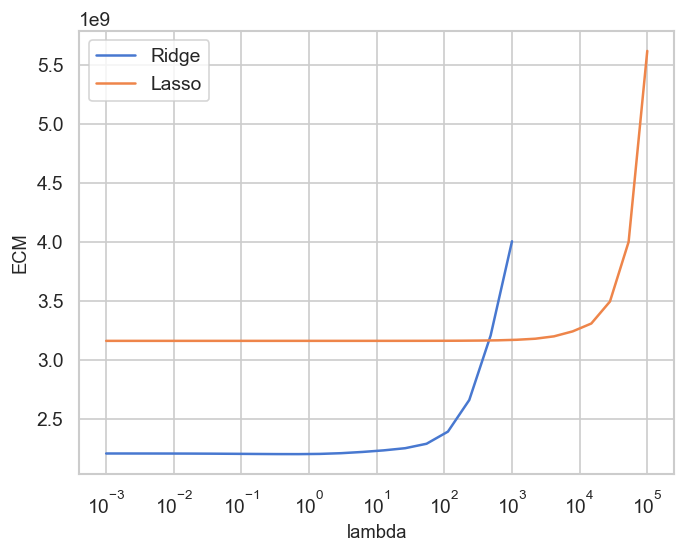

In [287]:
# Comparación del ECM de validación cruzada para Ridge y Lasso en un mismo gráfico
plt.plot(lambdas_L2, list(errors_l2.values()), label="Ridge")
plt.plot(lambdas_L1, list(errors_l1.values()), label="Lasso")

plt.xscale("log")
plt.xlabel("lambda")
plt.ylabel("ECM")
plt.legend()
plt.show()

In [288]:
# Lambdas óptimos seleccionados por validación cruzada
print("Lambda óptimo por validación cruzada:s")
print(f"Lasso: {best_l1}")
print(f"Ridge: {best_l2}")

Lambda óptimo por validación cruzada:s
Lasso: 0.001
Ridge: 0.6951927961775606


In [289]:
# RMSE con el lambda óptimo — comparación entre Ridge y Lasso
print("RMSE (validación cruzada) con lambda óptimo:")
print("Lasso: ", np.sqrt(errors_l1[best_l1]))
print("Ridge: ", np.sqrt(errors_l2[best_l2]))

RMSE (validación cruzada) con lambda óptimo:
Lasso:  56244.69564136305
Ridge:  46950.74322127939


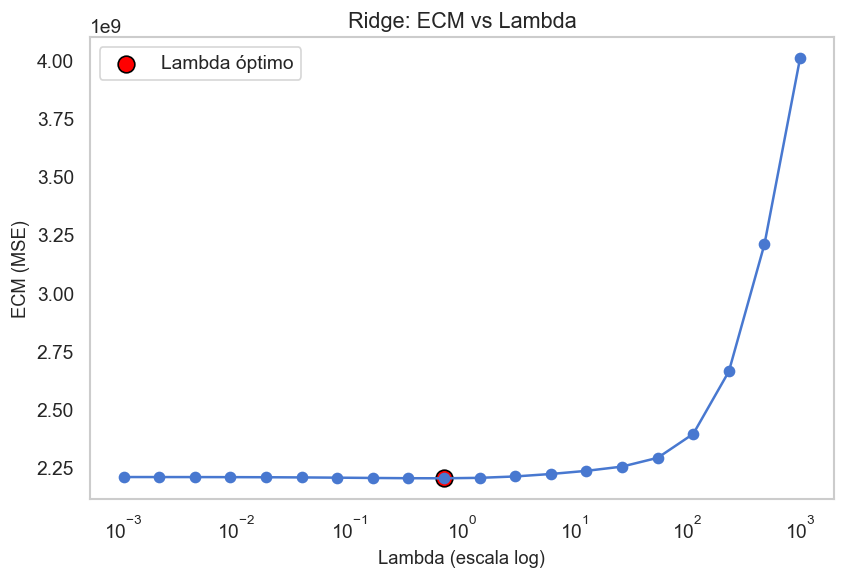

In [290]:
# Curva ECM vs. λ — Ridge con lambda óptimo resaltado
plt.figure(figsize=(8,5))

plt.plot(errors_l2.keys(), errors_l2.values(), marker='o')

plt.scatter(best_l2, errors_l2[best_l2], s=100, label="Lambda óptimo", c='red', edgecolors='black')

plt.xscale("log")
plt.xlabel("Lambda (escala log)")
plt.ylabel("ECM (MSE)")
plt.title("Ridge: ECM vs Lambda")

plt.legend()
plt.grid()
plt.show()

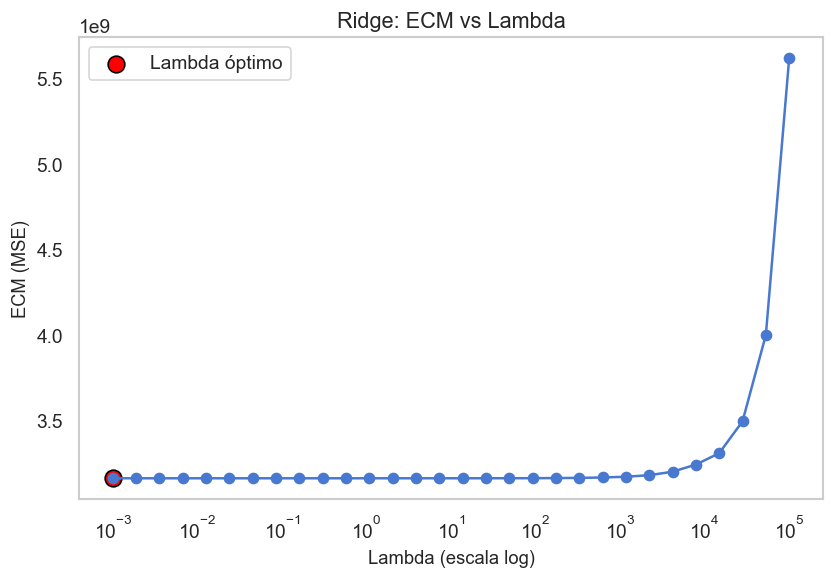

In [291]:
# Curva ECM vs. λ — Lasso con lambda óptimo resaltado
plt.figure(figsize=(8,5))

plt.plot(errors_l1.keys(), errors_l1.values(), marker='o')

plt.scatter(best_l1, errors_l1[best_l1], s=100, label="Lambda óptimo", c='red', edgecolors='black')

plt.xscale("log")
plt.xlabel("Lambda (escala log)")
plt.ylabel("ECM (MSE)")
plt.title("Ridge: ECM vs Lambda")

plt.legend()
plt.grid()
plt.show()

In [292]:
# M6: modelo Ridge con el λ óptimo encontrado por validación cruzada
# Se usan las mismas features que M4 (11 features)

model_M6 = LinearRegression(X_train_M4, y_train, l2=best_l2, l1=0)

model_M6.pseudo_inverse()

y_pred_M6_train = model_M6.predict_inv(X_train_M4)
y_pred_M6_val = model_M6.predict_inv(X_val_M4)

print(f"M6 Ridge (λ={best_l2:.4f}) — RMSE train: {rmse(y_train, y_pred_M6_train):.2f}")
print(f"M6 Ridge (λ={best_l2:.4f}) — RMSE val:   {rmse(y_val,   y_pred_M6_val):.2f}")
print()
print("Referencia — M4 sin regularización:")
print(f"  M4 — RMSE train: {rmse(y_train, y_pred_M4_inv_train):.2f}")
print(f"  M4 — RMSE val:   {rmse(y_val,   y_pred_M4_inv_val):.2f}")

M6 Ridge (λ=0.6952) — RMSE train: 47908.06
M6 Ridge (λ=0.6952) — RMSE val:   40370.44

Referencia — M4 sin regularización:
  M4 — RMSE train: 47850.98
  M4 — RMSE val:   40532.85


**por qué la regularización no mejora significativamente sobre M4???**

Este resultado se debe a que la regularización aporta mayor beneficio cuando el modelo tiene **alta varianza**, osea overfitting. Al parecer, las features utilizadas en M4, junto con el proceso de normalización, generan una matriz de diseño bien condicionada, lo que permite que la estimación por pseudo-inversa sea numéricamente estable y no presente coeficientes excesivamente grandes. En linea con esto, la regularización es más efectiva cuando los coeficientes crecen descontroladamente o la matriz de diseño es mal condicionada, lo cual no ocurre en este modelo. Es por esto que la regularización no aporta beneficios adicionales en este caso particular.

## Ejercicio 6: Selección de Modelo y Evaluación de Capacidad Predictiva

### 6.1 Learning Curves

La *learning curve* muestra cómo evoluciona el error de train y de validación a medida que se incrementa el tamaño del conjunto de entrenamiento.

In [293]:
# IMPORTS

from utils import learning_curve_model

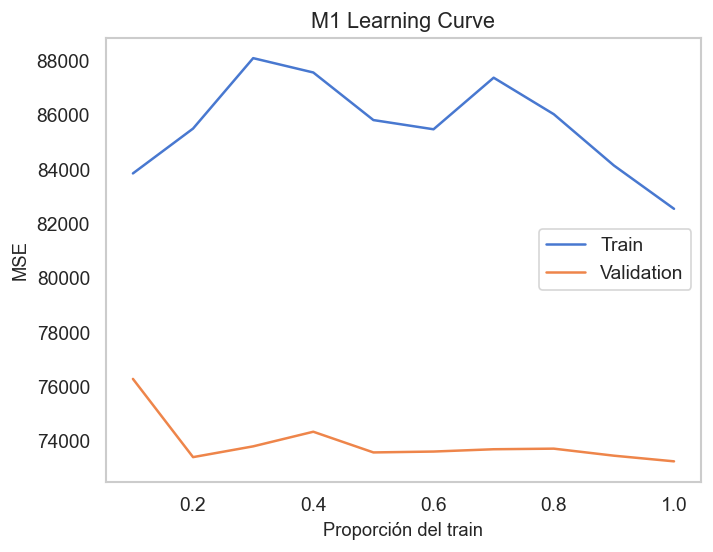

In [294]:
sizes, train_err, val_err = learning_curve_model(train, val, "M1")

plt.plot(sizes, train_err, label="Train")
plt.plot(sizes, val_err, label="Validation")

plt.xlabel("Proporción del train")
plt.ylabel("MSE")
plt.title("M1 Learning Curve")
plt.legend()
plt.grid()
plt.show()

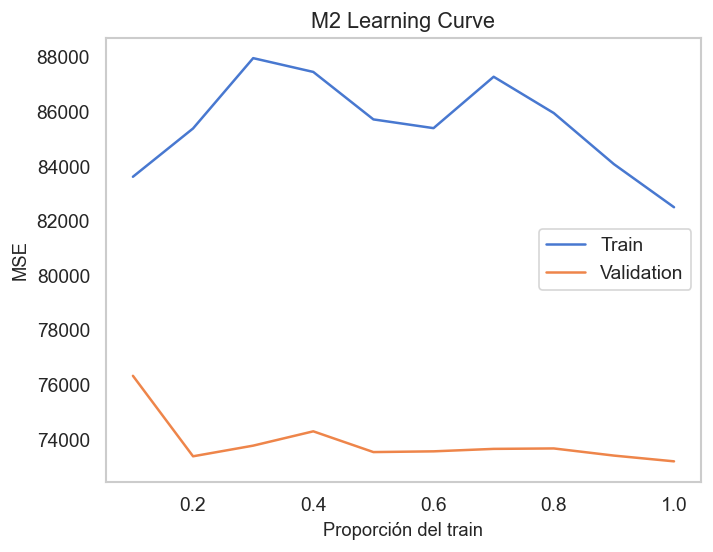

In [295]:
sizes, train_err, val_err = learning_curve_model(train, val, "M2")

plt.plot(sizes, train_err, label="Train")
plt.plot(sizes, val_err, label="Validation")

plt.xlabel("Proporción del train")
plt.ylabel("MSE")
plt.title("M2 Learning Curve")
plt.legend()
plt.grid()
plt.show()

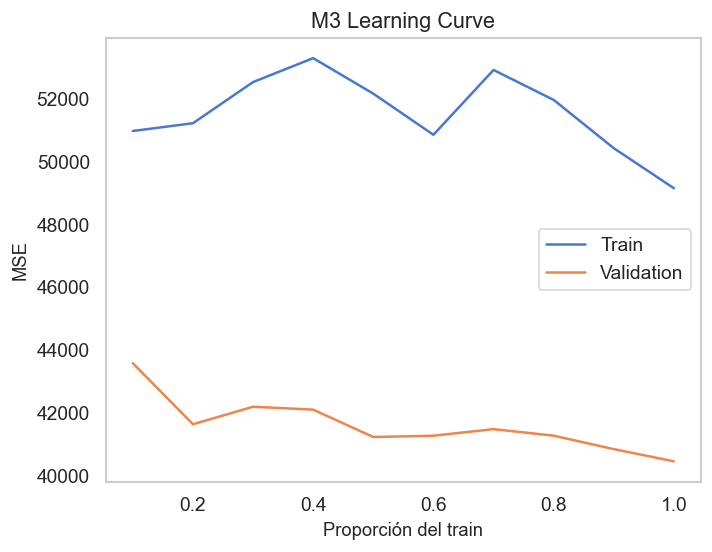

In [296]:
sizes, train_err, val_err = learning_curve_model(train, val, "M3")

plt.plot(sizes, train_err, label="Train")
plt.plot(sizes, val_err, label="Validation")

plt.xlabel("Proporción del train")
plt.ylabel("MSE")
plt.title("M3 Learning Curve")
plt.legend()
plt.grid()
plt.show()

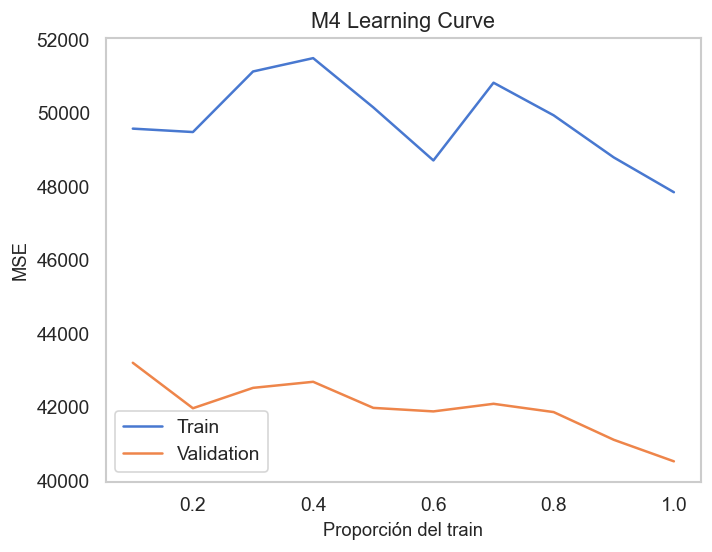

In [297]:
sizes, train_err, val_err = learning_curve_model(train, val, "M4")

plt.plot(sizes, train_err, label="Train")
plt.plot(sizes, val_err, label="Validation")

plt.xlabel("Proporción del train")
plt.ylabel("MSE")
plt.title("M4 Learning Curve")
plt.legend()
plt.grid()
plt.show()

  [normalize] Advertencia: feature 'tipo_otro' tiene desvío ≈ 0 → se reemplaza por 0.
  [normalize] Advertencia: feature 'tipo_otro' tiene desvío ≈ 0 → se reemplaza por 0.
  [normalize] Advertencia: feature 'tipo_otro' tiene desvío ≈ 0 → se reemplaza por 0.
  [normalize] Advertencia: feature 'tipo_otro' tiene desvío ≈ 0 → se reemplaza por 0.
  [normalize] Advertencia: feature 'tipo_otro' tiene desvío ≈ 0 → se reemplaza por 0.
  [normalize] Advertencia: feature 'tipo_otro' tiene desvío ≈ 0 → se reemplaza por 0.
  [normalize] Advertencia: feature 'tipo_otro' tiene desvío ≈ 0 → se reemplaza por 0.
  [normalize] Advertencia: feature 'tipo_otro' tiene desvío ≈ 0 → se reemplaza por 0.
  [normalize] Advertencia: feature 'tipo_otro' tiene desvío ≈ 0 → se reemplaza por 0.
  [normalize] Advertencia: feature 'tipo_otro' tiene desvío ≈ 0 → se reemplaza por 0.


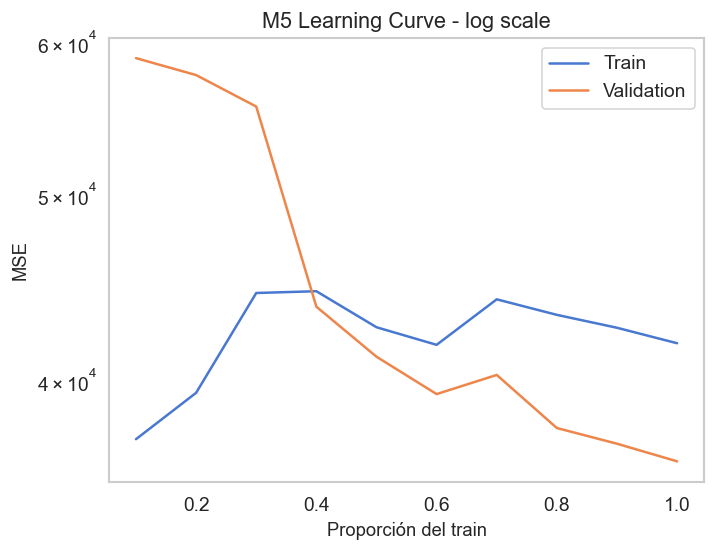

In [298]:
sizes, train_err, val_err = learning_curve_model(train, val, "M5")

plt.plot(sizes, train_err, label="Train")
plt.plot(sizes, val_err, label="Validation")

plt.yscale('log')

plt.xlabel("Proporción del train")
plt.ylabel("MSE")
plt.title("M5 Learning Curve - log scale")
plt.legend()
plt.grid()
plt.show()

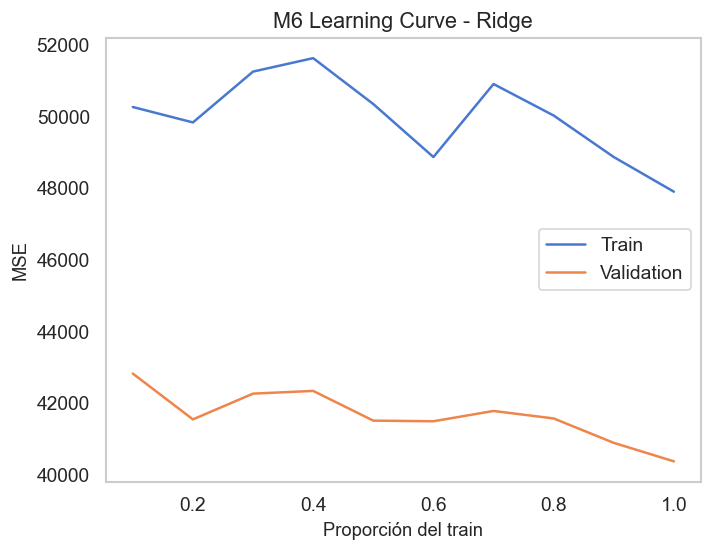

In [299]:
sizes, train_err, val_err = learning_curve_model(train, val, "M6", best_l2=best_l2)

plt.plot(sizes, train_err, label="Train")
plt.plot(sizes, val_err, label="Validation")

plt.xlabel("Proporción del train")
plt.ylabel("MSE")
plt.title("M6 Learning Curve - Ridge")
plt.legend()
plt.grid()
plt.show()

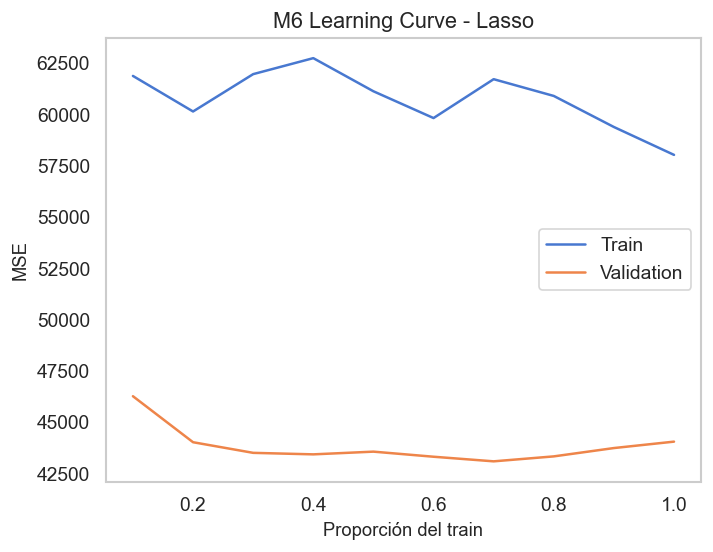

In [300]:
sizes, train_err, val_err = learning_curve_model(train, val, "M6", best_l1=best_l1)

plt.plot(sizes, train_err, label="Train")
plt.plot(sizes, val_err, label="Validation")

plt.xlabel("Proporción del train")
plt.ylabel("MSE")
plt.title("M6 Learning Curve - Lasso")
plt.legend()
plt.grid()
plt.show()

**Análisis de las learning curves:**

- **M1 y M2:** error alto y constante en ambas curvas → **underfitting claro**. Agregar más datos no ayuda porque el modelo es demasiado simple para capturar la complejidad del problema. La curva de validación converge a la de train pero a valores inaceptablemente altos.
- **M3:** mejora notoria. La brecha entre train y validación se reduce y los errores bajan. La latitud agrega información crítica sobre el mercado.
- **M4:** comportamiento similar a M3 con error levemente menor. Las learning curves están cercanas y con tendencia decreciente, indicando buen balance bias-varianza. Agregar más datos seguiría mejorando el modelo.
- **M5:** brecha amplia entre train (bajo) y validación (alto) → **overfitting**. Con más datos la brecha se reduciría gradualmente, pero con el tamaño actual del dataset la varianza domina. Se usa escala log porque los valores son muy disímiles.
- **M6 Ridge/Lasso:** comportamiento muy similar a M4, con leve mejora en estabilidad para subconjuntos pequeños gracias a la regularización.

### 6.2 Selección del modelo para producción

**Modelo seleccionado: M6 con regularización Ridge (L2)**

**Justificación:**

1. **Mejor error de validación cruzada:** M6 Ridge obtiene el menor RMSE estimado entre todos los modelos evaluados mediante CV, lo que indica mejor capacidad predictiva sobre datos no vistos.

2. **Balance bias-varianza adecuado:** su learning curve muestra que train y validación convergen con errores bajos y brecha pequeña, sin el underfitting de M1-M2 ni el overfitting de M5.

3. **Robustez ante variaciones:** la regularización Ridge actúa como mecanismo de control de complejidad, haciendo el modelo más estable ante propiedades con características inusuales en producción. ESTO ES LO QUE ME CONVENCE ANTE EL MODELO M4, TEORICAMENTE ES MEJOR CON REGULARIZACION!

### 6.3 Entrenamiento final y evaluación sobre test

Para la evaluación final se entrena el modelo seleccionado sobre **todo el conjunto de desarrollo** (train + validación) y se reportan las métricas sobre el conjunto de test, que no fue utilizado en ningún paso previo del desarrollo.

In [301]:
# Carga del conjunto de test y preprocesamiento con el mismo pipeline

df_test = pd.read_csv("../data/raw/casas_test.csv")
df_test_processed = preprocess(df_test)

df_train = pd.read_csv("../data/raw/casas_dev.csv")
df_processed = preprocess(df_train)



In [302]:
# Separación de features y target para train completo y test
y_full_train = df_processed['precio'].values.copy()
y_test = df_test_processed['precio'].values.copy()

X_full_train = df_processed.drop(columns=['precio'])
X_test = df_test_processed.drop(columns=['precio'])

In [303]:
# Pipeline completo sobre train completo y test:
# Las estadísticas de imputación y normalización se calculan sobre X_full_train
# y se aplican a X_test para evitar data leakage del test set

X_full_train, X_test = fill_edad_median(X_full_train, X_test)
X_full_train, X_test = one_hot_encoder(X_full_train, X_test)

X_full_train_fe = feature_engineering(X_full_train)
X_test_fe = feature_engineering(X_test)

# Selección de las mismas features que M6 (igual que en el entrenamiento)
features_final = ["Área", "metros_cubiertos" ,"ambientes","pileta","lat","edad", "area_log", "area_sq", "densidad",
    "area_pileta", "ambientes_por_area"]

X_full_train = X_full_train_fe[features_final]
X_test = X_test_fe[features_final]

X_full_train_norm, X_test_norm = normalize(X_full_train, X_test)

In [304]:
# Entrenamiento del modelo final sobre todo el conjunto de desarrollo
model_FINAL = LinearRegression(X_full_train_norm, y_full_train, l2=best_l2, l1=0)

model_FINAL.pseudo_inverse()

y_pred_FINAL_train = model_FINAL.predict_inv(X_full_train_norm)
y_pred_FINAL_test = model_FINAL.predict_inv(X_test_norm)

print("══════════════════════════════════════")
print("   EVALUACIÓN FINAL — Modelo M6 Ridge")
print("══════════════════════════════════════")
print(f"RMSE sobre test: {rmse(y_test, y_pred_FINAL_test):.2f} USD")
print(f"MAE  sobre test: {mae(y_test,  y_pred_FINAL_test):.2f} USD")
print()
print(f"(referencia — RMSE sobre train completo: {rmse(y_full_train, y_pred_FINAL_train):.2f} USD)")

══════════════════════════════════════
   EVALUACIÓN FINAL — Modelo M6 Ridge
══════════════════════════════════════
RMSE sobre test: 45039.62 USD
MAE  sobre test: 29184.30 USD

(referencia — RMSE sobre train completo: 46428.94 USD)


**Interpretación de los resultados finales:**

- **RMSE ≈ 45.040 USD:** el modelo se equivoca en promedio ~45K dólares por propiedad. Es un error considerable en términos absolutos, pero esperable dado que el dataset mezcla dos mercados con precios muy distintos (Buenos Aires y Nueva York) sin separación explícita en el modelo.
- **MAE ≈ 29.184 USD:** el error absoluto medio es significativamente menor al RMSE. Esta diferencia indica que hay algunas propiedades con errores muy grandes que elevan el RMSE sin representar el error "típico".
- **Sin overfitting:** la diferencia entre RMSE de train y de test es pequeña, lo que confirma que el modelo generaliza correctamente y no memorizó el conjunto de entrenamiento.